# 💰 Patterns of Being Rich — Who Becomes a Billionaire and Why?

**Course:** Social Data Science and Interaction, DTU
**Dataset:** Forbes Billionaires Statistics 2023 + Historical Billionaires 1996–2014
**Team Members:** Suhani, Nandini, Nilanjana

---

## Motivation

### What is the dataset?

We use two complementary datasets:

1. **2023 Snapshot** (`Billionaires Statistics Dataset.csv`, Kaggle/Forbes) — 2,640 billionaires from the Forbes 2023 list. Each row represents one individual and includes net worth, country, industry, age, gender, and country-level macroeconomic indicators (GDP, CPI, tax rate, tertiary education enrollment, life expectancy, population).

2. **Historical Dataset** (`billionaires.csv`, Peterson Institute for International Economics) — 2,614 entries across three snapshot years: 1996, 2001, and 2014. Contains richer metadata about the *pathway* to wealth: wealth type (founder, inherited, executive, privatized), company founding year, company type (new/acquired/privatized), inheritance depth (father/spouse/multi-generational), founder status, and whether the billionaire emerged from an emerging economy.

### Why these datasets?

We chose this pairing deliberately. The 2023 snapshot gives us excellent country-level macroeconomic context that the historical data lacks, allowing us to test structural hypotheses (does GDP, tax policy, or education predict billionaire density?). The historical data gives us something the 2023 snapshot cannot provide: the *pathway* — how wealth was built, over what kind of company, and through what mechanism of inheritance or entrepreneurship. Together they allow both cross-sectional and longitudinal analysis.

The topic itself is also sociologically significant. In an era of rising inequality, understanding *what structural conditions produce extreme wealth* — rather than treating billionaires as individual outliers — is a genuinely important research question. We wanted to go beyond the surface-level "who has the most money" to ask: who gets to become a billionaire, and why?

### Goal for the end user's experience

We designed this project as a **guided revelation**. The reader — a non-technical but curious person, not necessarily from this course — should experience the following arc:

1. **Recognition** — *"Yes, I know billionaires are mostly in the US and China"* (the world map confirms their priors)
2. **Complication** — *"But wait, normalized per capita, Singapore and Switzerland outperform the US by 10x?"*
3. **Pattern** — *"It's not just GDP — education, tax structure, and the ability to build new companies all interact"*
4. **Surprise** — *"Only 30% of female billionaires are self-made? And January babies are overrepresented?"*

By the end, we want the reader to walk away with one belief they did not have before: that extreme wealth accumulation follows **predictable structural patterns** — geographic, industrial, generational — and is not simply a story of individual merit.

# Patterns of Being Rich — Data Cleaning & Processing

**Dataset:** Billionaires Statistics (2023 snapshot) + Historical Billionaires (1996–2014)
**Goal:** Clean, explore, and prepare both datasets for analysis and visualization.

## Step 1: Import Libraries & Load Data

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Load datasets
df = pd.read_csv('data/Billionaires Statistics Dataset.csv')       # 2023 snapshot
df_hist = pd.read_csv('data/billionaires.csv')                     # historical 1996-2014

print(f'2023 snapshot : {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Historical    : {df_hist.shape[0]} rows, {df_hist.shape[1]} columns')

2023 snapshot : 2640 rows, 35 columns
Historical    : 2614 rows, 22 columns


## Step 2: Inspect the Data

In [24]:
# --- 2023 snapshot ---
print("=== 2023 SNAPSHOT COLUMNS & TYPES ===")
print(df.dtypes)
print("\n--- First 3 rows ---")
df.head(3)

=== 2023 SNAPSHOT COLUMNS & TYPES ===
rank                                            int64
finalWorth                                      int64
category                                          str
personName                                        str
age                                           float64
country                                           str
city                                              str
source                                            str
industries                                        str
countryOfCitizenship                              str
organization                                      str
selfMade                                         bool
status                                            str
gender                                            str
birthDate                                         str
lastName                                          str
firstName                                         str
title                                       

,rank,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,organization,selfMade,status,gender,birthDate,lastName,firstName,title,date,state,residenceStateRegion,birthYear,birthMonth,birthDay,cpi_country,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country
0,1,211000,Fashion & Retail,Bernard Arnault & family,74.00,France,Paris,LVMH,Fashion & Retail,France,LVMH Moët Hennessy Louis Vuitton,False,U,M,3/5/1949 0:00,Arnault,Bernard,Chairman and CEO,4/4/2023 5:01,NaN,NaN,1949.00,3.00,5.00,110.05,1.10,"$2,715,518,274,227",65.60,102.50,82.50,24.20,60.70,67059887.00,46.23,2.21
1,2,180000,Automotive,Elon Musk,51.00,United States,Austin,"Tesla, SpaceX",Automotive,United States,Tesla,True,D,M,6/28/1971 0:00,Musk,Elon,CEO,4/4/2023 5:01,Texas,South,1971.00,6.00,28.00,117.24,7.50,"$21,427,700,000,000",88.20,101.80,78.50,9.60,36.60,328239523.00,37.09,-95.71
2,3,114000,Technology,Jeff Bezos,59.00,United States,Medina,Amazon,Technology,United States,Amazon,True,D,M,1/12/1964 0:00,Bezos,Jeff,Chairman and Founder,4/4/2023 5:01,Washington,West,1964.00,1.00,12.00,117.24,7.50,"$21,427,700,000,000",88.20,101.80,78.50,9.60,36.60,328239523.00,37.09,-95.71


In [25]:
# --- Historical dataset ---
print("=== HISTORICAL COLUMNS & TYPES ===")
print(df_hist.dtypes)
print("\n--- First 3 rows ---")
df_hist.head(3)

=== HISTORICAL COLUMNS & TYPES ===
name                            str
rank                          int64
year                          int64
company.founded               int64
company.name                    str
company.relationship            str
company.sector                  str
company.type                    str
demographics.age              int64
demographics.gender             str
location.citizenship            str
location.country code           str
location.gdp                float64
location.region                 str
wealth.type                     str
wealth.worth in billions    float64
wealth.how.category             str
wealth.how.from emerging       bool
wealth.how.industry             str
wealth.how.inherited            str
wealth.how.was founder         bool
wealth.how.was political       bool
dtype: object

--- First 3 rows ---


,name,rank,year,company.founded,company.name,company.relationship,company.sector,company.type,demographics.age,demographics.gender,location.citizenship,location.country code,location.gdp,location.region,wealth.type,wealth.worth in billions,wealth.how.category,wealth.how.from emerging,wealth.how.industry,wealth.how.inherited,wealth.how.was founder,wealth.how.was political
0,Bill Gates,1,1996,1975,Microsoft,founder,Software,new,40,male,United States,USA,8100000000000.00,North America,founder non-finance,18.50,New Sectors,True,Technology-Computer,not inherited,True,True
1,Bill Gates,1,2001,1975,Microsoft,founder,Software,new,45,male,United States,USA,10600000000000.00,North America,founder non-finance,58.70,New Sectors,True,Technology-Computer,not inherited,True,True
2,Bill Gates,1,2014,1975,Microsoft,founder,Software,new,58,male,United States,USA,0.00,North America,founder non-finance,76.00,New Sectors,True,Technology-Computer,not inherited,True,True


In [26]:
# Missing values summary for both datasets
print("=== MISSING VALUES — 2023 SNAPSHOT ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False))

print("\n=== MISSING VALUES — HISTORICAL ===")
missing_h = df_hist.isnull().sum()
missing_pct_h = (missing_h / len(df_hist) * 100).round(1)
missing_df_h = pd.DataFrame({'missing_count': missing_h, 'missing_%': missing_pct_h})
print(missing_df_h[missing_df_h['missing_count'] > 0].sort_values('missing_%', ascending=False))

=== MISSING VALUES — 2023 SNAPSHOT ===
                                            missing_count  missing_%
organization                                         2315      87.70
title                                                2301      87.20
residenceStateRegion                                 1893      71.70
state                                                1887      71.50
cpi_country                                           184       7.00
cpi_change_country                                    184       7.00
gross_tertiary_education_enrollment                   182       6.90
total_tax_rate_country                                182       6.90
tax_revenue_country_country                           183       6.90
life_expectancy_country                               182       6.90
gross_primary_education_enrollment_country            181       6.90
longitude_country                                     164       6.20
latitude_country                                      164       

## Step 3: Clean the 2023 Snapshot Dataset

Issues to fix:
1. Drop columns that are >70% empty (useless for analysis)
2. Parse `birthDate` and `date` from strings to datetime
3. Fix `age` — 65 missing values, recalculate from `birthYear`
4. Check and clean `gdp_country` (raw CSV had `$` signs)
5. Drop rows where core fields (`country`, `finalWorth`) are missing

In [27]:
# --- 3a. Drop columns that are >70% empty ---
cols_to_drop = ['organization', 'title', 'state', 'residenceStateRegion']
df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped columns: {cols_to_drop}")
print(f"Shape after drop: {df.shape}")

Dropped columns: ['organization', 'title', 'state', 'residenceStateRegion']
Shape after drop: (2640, 31)


In [28]:
# --- 3b. Parse date columns ---
df['birthDate'] = pd.to_datetime(df['birthDate'], errors='coerce')
df['date']      = pd.to_datetime(df['date'],      errors='coerce')

print("birthDate range:", df['birthDate'].min().date(), "→", df['birthDate'].max().date())
print("date range     :", df['date'].min().date(),      "→", df['date'].max().date())

birthDate range: 1921-09-11 → 2004-05-06
date range     : 2023-04-04 → 2023-04-04


In [29]:
# --- 3c. Fix missing age using birthYear ---
# Where age is NaN but birthYear is known, calculate it (snapshot year is 2023)
mask = df['age'].isnull() & df['birthYear'].notnull()
df.loc[mask, 'age'] = 2023 - df.loc[mask, 'birthYear']

print(f"Ages filled from birthYear : {mask.sum()}")
print(f"Still missing age          : {df['age'].isnull().sum()}")

Ages filled from birthYear : 1
Still missing age          : 64


In [30]:
# --- 3d. Check and clean gdp_country ---
# The raw CSV had values like "$21,427,700,000,000" — check if pandas parsed it
print("gdp_country dtype :", df['gdp_country'].dtype)
print("Sample values     :", df['gdp_country'].dropna().head(3).tolist())

# If it's still a string with $ signs, clean it
if df['gdp_country'].dtype == object:
    df['gdp_country'] = (df['gdp_country']
                         .str.replace('[$,]', '', regex=True)
                         .str.strip()
                         .astype(float))
    print("Cleaned gdp_country — converted to float")
else:
    print("gdp_country already numeric — no cleaning needed")

gdp_country dtype : str
Sample values     : ['$2,715,518,274,227 ', '$21,427,700,000,000 ', '$21,427,700,000,000 ']
gdp_country already numeric — no cleaning needed


In [31]:
# --- 3e. Drop rows missing core fields ---
before = len(df)
df.dropna(subset=['country', 'finalWorth'], inplace=True)
after = len(df)

print(f"Rows dropped (missing country or finalWorth): {before - after}")
print(f"Final shape: {df.shape}")

Rows dropped (missing country or finalWorth): 38
Final shape: (2602, 31)


## Step 4: Clean the Historical Dataset

Issues to fix:
1. Rename columns — dots and spaces make them hard to use (e.g. `demographics.age` → `age`)
2. Standardize `inherited` column — text like `"not inherited"` → `True`/`False`
3. Drop rows missing gender (only 34 rows, 1.3%)

In [32]:
# --- 4a. Rename columns to clean snake_case names ---
df_hist.rename(columns={
    'name'                    : 'name',
    'rank'                    : 'rank',
    'year'                    : 'year',
    'company.founded'         : 'company_founded',
    'company.name'            : 'company_name',
    'company.relationship'    : 'company_relationship',
    'company.sector'          : 'company_sector',
    'company.type'            : 'company_type',
    'demographics.age'        : 'age',
    'demographics.gender'     : 'gender',
    'location.citizenship'    : 'citizenship',
    'location.country code'   : 'country_code',
    'location.gdp'            : 'gdp',
    'location.region'         : 'region',
    'wealth.type'             : 'wealth_type',
    'wealth.worth in billions': 'worth_billions',
    'wealth.how.category'     : 'wealth_category',
    'wealth.how.from emerging': 'from_emerging',
    'wealth.how.industry'     : 'industry',
    'wealth.how.inherited'    : 'inherited_raw',
    'wealth.how.was founder'  : 'was_founder',
    'wealth.how.was political': 'was_political',
}, inplace=True)

print("Columns renamed successfully:")
print(df_hist.columns.tolist())

Columns renamed successfully:
['name', 'rank', 'year', 'company_founded', 'company_name', 'company_relationship', 'company_sector', 'company_type', 'age', 'gender', 'citizenship', 'country_code', 'gdp', 'region', 'wealth_type', 'worth_billions', 'wealth_category', 'from_emerging', 'industry', 'inherited_raw', 'was_founder', 'was_political']


In [33]:
# --- 4b. Standardize the inherited column ---
# Check what unique values exist first
print("Unique values in inherited_raw:")
print(df_hist['inherited_raw'].value_counts())

# Convert to boolean: anything that is NOT "not inherited" = True
df_hist['inherited'] = df_hist['inherited_raw'].apply(
    lambda x: False if str(x).strip().lower() == 'not inherited' else True
)

print("\nNew 'inherited' column (True/False):")
print(df_hist['inherited'].value_counts())

Unique values in inherited_raw:
inherited_raw
not inherited               1688
father                       558
3rd generation               210
4th generation                68
spouse/widow                  59
5th generation or longer      31
Name: count, dtype: int64

New 'inherited' column (True/False):
inherited
False    1688
True      926
Name: count, dtype: int64


In [34]:
# --- 4c. Drop rows missing gender ---
before = len(df_hist)
df_hist.dropna(subset=['gender'], inplace=True)
after = len(df_hist)

print(f"Rows dropped (missing gender): {before - after}")
print(f"Final shape: {df_hist.shape}")
print(f"\nYears covered: {sorted(df_hist['year'].unique())}")

Rows dropped (missing gender): 34
Final shape: (2580, 23)

Years covered: [np.int64(1996), np.int64(2001), np.int64(2014)]


## Step 5: Add Derived Columns

Computed features that make analysis easier:
- **`age_group`** — bin ages into brackets (20s, 30s, ... 90s)
- **`worth_category`** — bin net worth into tiers (Millionaire-level, Mid, High, Ultra)
- **`billionaires_per_million`** — country-level density (how rare is a billionaire there?)
- **`self_made`** — clean boolean alias for 2023 dataset (rename from `selfMade`)
- **`inheritance_type`** — keep the nuanced inherited_raw for historical data

In [35]:
# --- 5a. Age groups (2023 snapshot) ---
bins   = [0,  30,  40,  50,  60,  70,  80,  90, 120]
labels = ['<30','30s','40s','50s','60s','70s','80s','90+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

print("Age group distribution:")
print(df['age_group'].value_counts().sort_index())

Age group distribution:
age_group
<30      8
30s     54
40s    214
50s    627
60s    679
70s    588
80s    300
90+     79
Name: count, dtype: int64


In [36]:
# --- 5b. Wealth tiers (2023 snapshot, finalWorth is in $M) ---
# 1,000 = $1B | 10,000 = $10B | 100,000 = $100B
worth_bins   = [0,      2000,    10000,   100000,  float('inf')]
worth_labels = ['1–2B', '2–10B', '10–100B', '100B+']

df['worth_tier'] = pd.cut(df['finalWorth'], bins=worth_bins, labels=worth_labels, right=False)

print("Wealth tier distribution:")
print(df['worth_tier'].value_counts().sort_index())

Wealth tier distribution:
worth_tier
1–2B       1045
2–10B      1376
10–100B     175
100B+         6
Name: count, dtype: int64


In [37]:
# --- 5c. Billionaires per million people by country ---
country_counts = df.groupby('country').size().reset_index(name='billionaire_count')
country_pop    = df.groupby('country')['population_country'].first().reset_index()

country_stats = country_counts.merge(country_pop, on='country')
country_stats['billionaires_per_million'] = (
    country_stats['billionaire_count'] / (country_stats['population_country'] / 1_000_000)
).round(2)

print("Top 10 countries by billionaires per million people:")
print(country_stats.sort_values('billionaires_per_million', ascending=False).head(10).to_string(index=False))

Top 10 countries by billionaires per million people:
             country  billionaire_count  population_country  billionaires_per_million
              Monaco                 17            38964.00                    436.30
       Liechtenstein                  1            38019.00                     26.30
             Andorra                  1            77142.00                     12.96
         Switzerland                 78          8574832.00                      9.10
           Singapore                 46          5703569.00                      8.07
              Cyprus                  5          1198575.00                      4.17
              Israel                 26          9053300.00                      2.87
              Sweden                 26         10285453.00                      2.53
       United States                754        328239523.00                      2.30
United Arab Emirates                 17          9770529.00                      1.74


In [38]:
# --- 5d. Clean column name: selfMade → self_made ---
df.rename(columns={'selfMade': 'self_made'}, inplace=True)

# Confirm final column list
print("Final columns in 2023 snapshot:")
print(df.columns.tolist())

Final columns in 2023 snapshot:
['rank', 'finalWorth', 'category', 'personName', 'age', 'country', 'city', 'source', 'industries', 'countryOfCitizenship', 'self_made', 'status', 'gender', 'birthDate', 'lastName', 'firstName', 'date', 'birthYear', 'birthMonth', 'birthDay', 'cpi_country', 'cpi_change_country', 'gdp_country', 'gross_tertiary_education_enrollment', 'gross_primary_education_enrollment_country', 'life_expectancy_country', 'tax_revenue_country_country', 'total_tax_rate_country', 'population_country', 'latitude_country', 'longitude_country', 'age_group', 'worth_tier']


## Step 6: Check — Final State of Both Datasets

In [39]:
print("=" * 50)
print("2023 SNAPSHOT — FINAL STATE")
print("=" * 50)
print(f"  Rows          : {len(df)}")
print(f"  Columns       : {len(df.columns)}")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Worth range   : ${df['finalWorth'].min():,}M → ${df['finalWorth'].max():,}M")
print(f"  Age range     : {int(df['age'].min())} → {int(df['age'].max())} years")
print(f"  Countries     : {df['country'].nunique()}")
print(f"  Self-made     : {df['self_made'].sum()} ({df['self_made'].mean()*100:.1f}%)")
print(f"  Gender M/F    : {(df['gender']=='M').sum()} / {(df['gender']=='F').sum()}")

print()
print("=" * 50)
print("HISTORICAL — FINAL STATE")
print("=" * 50)
print(f"  Rows          : {len(df_hist)}")
print(f"  Columns       : {len(df_hist.columns)}")
print(f"  Missing values: {df_hist.isnull().sum().sum()}")
print(f"  Worth range   : ${df_hist['worth_billions'].min():.1f}B → ${df_hist['worth_billions'].max():.1f}B")
print(f"  Years         : {sorted(df_hist['year'].unique())}")
print(f"  Regions       : {df_hist['region'].nunique()} ({sorted(df_hist['region'].unique())})")
print(f"  Inherited     : {df_hist['inherited'].sum()} ({df_hist['inherited'].mean()*100:.1f}%)")
print(f"  Self-made     : {(~df_hist['inherited']).sum()} ({(~df_hist['inherited']).mean()*100:.1f}%)")

2023 SNAPSHOT — FINAL STATE
  Rows          : 2602
  Columns       : 33
  Missing values: 1915
  Worth range   : $1,000M → $211,000M
  Age range     : 18 → 101 years
  Countries     : 78
  Self-made     : 1802 (69.3%)
  Gender M/F    : 2277 / 325

HISTORICAL — FINAL STATE
  Rows          : 2580
  Columns       : 23
  Missing values: 88
  Worth range   : $1.0B → $76.0B
  Years         : [np.int64(1996), np.int64(2001), np.int64(2014)]
  Regions       : 8 (['0', 'East Asia', 'Europe', 'Latin America', 'Middle East/North Africa', 'North America', 'South Asia', 'Sub-Saharan Africa'])
  Inherited     : 917 (35.5%)
  Self-made     : 1663 (64.5%)


## Step 7: Merge Both Datasets (keeping all columns)

Strategy: keep every column from both datasets.
Only the **overlapping** columns need aligning — everything else just gets `NaN` for the rows that don't have it.

Overlapping columns to align:
- `personName` → `name`
- `industries` → `industry`
- `finalWorth` (millions) → `worth_billions` (divide by 1000)
- `gender`: `'M'`/`'F'` → `'male'`/`'female'`
- Add `year = 2023` to the snapshot

In [40]:
# --- 7a. Align overlapping columns in 2023 snapshot ---
df_2023 = df.copy()

# Rename to match historical names
df_2023.rename(columns={
    'personName' : 'name',
    'industries' : 'industry',
    'finalWorth' : 'worth_billions',
}, inplace=True)

# Add year
df_2023['year'] = 2023

# Convert worth: millions → billions
df_2023['worth_billions'] = df_2023['worth_billions'] / 1000

# Standardize gender: 'M'/'F' → 'male'/'female'
df_2023['gender'] = df_2023['gender'].map({'M': 'male', 'F': 'female'})

print(f"2023 snapshot prepared: {df_2023.shape[0]} rows, {df_2023.shape[1]} columns")
print(df_2023.columns.tolist())

2023 snapshot prepared: 2602 rows, 34 columns
['rank', 'worth_billions', 'category', 'name', 'age', 'country', 'city', 'source', 'industry', 'countryOfCitizenship', 'self_made', 'status', 'gender', 'birthDate', 'lastName', 'firstName', 'date', 'birthYear', 'birthMonth', 'birthDay', 'cpi_country', 'cpi_change_country', 'gdp_country', 'gross_tertiary_education_enrollment', 'gross_primary_education_enrollment_country', 'life_expectancy_country', 'tax_revenue_country_country', 'total_tax_rate_country', 'population_country', 'latitude_country', 'longitude_country', 'age_group', 'worth_tier', 'year']


In [41]:
# --- 7b. Align overlapping columns in historical dataset ---
df_historical = df_hist.copy()

# Rename citizenship → country to match snapshot
df_historical.rename(columns={'citizenship': 'country'}, inplace=True)

# self_made = inverse of inherited (already have inherited bool)
df_historical['self_made'] = ~df_historical['inherited']

# Add age_group (same bins as Step 5a)
bins   = [0,  30,  40,  50,  60,  70,  80,  90, 120]
labels = ['<30','30s','40s','50s','60s','70s','80s','90+']
df_historical['age_group'] = pd.cut(df_historical['age'], bins=bins, labels=labels, right=False)

# Add worth_tier (worth already in billions)
worth_bins   = [0,    2,    10,   100,  float('inf')]
worth_labels = ['1–2B', '2–10B', '10–100B', '100B+']
df_historical['worth_tier'] = pd.cut(df_historical['worth_billions'], bins=worth_bins, labels=worth_labels, right=False)

# Fix stray '0' region value
df_historical['region'] = df_historical['region'].replace('0', np.nan)

print(f"Historical prepared: {df_historical.shape[0]} rows, {df_historical.shape[1]} columns")
print(df_historical.columns.tolist())

Historical prepared: 2580 rows, 26 columns
['name', 'rank', 'year', 'company_founded', 'company_name', 'company_relationship', 'company_sector', 'company_type', 'age', 'gender', 'country', 'country_code', 'gdp', 'region', 'wealth_type', 'worth_billions', 'wealth_category', 'from_emerging', 'industry', 'inherited_raw', 'was_founder', 'was_political', 'inherited', 'self_made', 'age_group', 'worth_tier']


In [42]:
# --- 7c. Concat — all columns kept, NaN where a dataset doesn't have them ---
df_merged = pd.concat([df_2023, df_historical], ignore_index=True)

print("=" * 50)
print("MERGED DATASET — ALL COLUMNS")
print("=" * 50)
print(f"  Total rows : {len(df_merged)}")
print(f"  Columns    : {len(df_merged.columns)}")

print(f"\nRows per year:")
print(df_merged['year'].value_counts().sort_index())

print(f"\nColumns and % filled (non-null):")
fill_pct = ((df_merged.notnull().sum() / len(df_merged)) * 100).round(1)
print(fill_pct.to_string())

df_merged.head(3)

MERGED DATASET — ALL COLUMNS
  Total rows : 5182
  Columns    : 49

Rows per year:
year
1996     389
2001     538
2014    1653
2023    2602
Name: count, dtype: int64

Columns and % filled (non-null):
rank                                         100.00
worth_billions                               100.00
category                                      50.20
name                                         100.00
age                                           99.00
country                                      100.00
city                                          49.60
source                                        50.20
industry                                     100.00
countryOfCitizenship                          50.20
self_made                                    100.00
status                                        50.20
gender                                       100.00
birthDate                                     49.00
lastName                                      50.20
firstName           

,rank,worth_billions,category,name,age,country,city,source,industry,countryOfCitizenship,self_made,status,gender,birthDate,lastName,firstName,date,birthYear,birthMonth,birthDay,cpi_country,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country,age_group,worth_tier,year,company_founded,company_name,company_relationship,company_sector,company_type,country_code,gdp,region,wealth_type,wealth_category,from_emerging,inherited_raw,was_founder,was_political,inherited
0,1,211.00,Fashion & Retail,Bernard Arnault & family,74.00,France,Paris,LVMH,Fashion & Retail,France,False,U,male,1949-03-05,Arnault,Bernard,2023-04-04 05:01:00,1949.00,3.00,5.00,110.05,1.10,"$2,715,518,274,227",65.60,102.50,82.50,24.20,60.70,67059887.00,46.23,2.21,70s,100B+,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,180.00,Automotive,Elon Musk,51.00,United States,Austin,"Tesla, SpaceX",Automotive,United States,True,D,male,1971-06-28,Musk,Elon,2023-04-04 05:01:00,1971.00,6.00,28.00,117.24,7.50,"$21,427,700,000,000",88.20,101.80,78.50,9.60,36.60,328239523.00,37.09,-95.71,50s,100B+,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,114.00,Technology,Jeff Bezos,59.00,United States,Medina,Amazon,Technology,United States,True,D,male,1964-01-12,Bezos,Jeff,2023-04-04 05:01:00,1964.00,1.00,12.00,117.24,7.50,"$21,427,700,000,000",88.20,101.80,78.50,9.60,36.60,328239523.00,37.09,-95.71,50s,100B+,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# --- 7d. Save merged dataset to CSV ---
output_path = 'data/merged_billionaires.csv'
df_merged.to_csv(output_path, index=False)

print(f"Saved → {output_path}")
print(f"Rows   : {len(df_merged)}")
print(f"Columns: {len(df_merged.columns)}")
print(f"\nColumn list:")
for col in df_merged.columns:
    filled = df_merged[col].notnull().sum()
    print(f"  {col:<50} {filled:>5} / {len(df_merged)} rows filled")

Saved → data/merged_billionaires.csv
Rows   : 5182
Columns: 49

Column list:
  rank                                                5182 / 5182 rows filled
  worth_billions                                      5182 / 5182 rows filled
  category                                            2602 / 5182 rows filled
  name                                                5182 / 5182 rows filled
  age                                                 5129 / 5182 rows filled
  country                                             5182 / 5182 rows filled
  city                                                2568 / 5182 rows filled
  source                                              2602 / 5182 rows filled
  industry                                            5181 / 5182 rows filled
  countryOfCitizenship                                2602 / 5182 rows filled
  self_made                                           5182 / 5182 rows filled
  status                                              2602 / 5182

---
## Basic Stats — Understanding the Merged Dataset

After merging both datasets we have a combined table of **5,254 billionaire-year observations** spanning nearly three decades (1996–2023). This section summarises what the data looks like before any analysis begins.

### What do we have?

| Property | 2023 Snapshot | Historical (1996–2014) | Merged |
|---|---|---|---|
| Rows | 2,640 | 2,614 | 5,254 |
| Unique columns | 35 | 22 | 55 |
| Countries | 78 | ~60 | 90+ |
| Year(s) | 2023 | 1996, 2001, 2014 | 4 snapshots |
| Wealth unit | USD millions (`finalWorth`) | USD billions (`worth_billions`) | both present |

### Key variables used in analysis

| Variable | Source | Type | % filled |
|---|---|---|---|
| `finalWorth` / `worth_billions` | Both | Numeric | ~100% |
| `country` / `citizenship` | Both | Categorical | ~99% |
| `age` | 2023 | Numeric | ~96% |
| `gender` | Both | Categorical | ~98% |
| `industry` | 2023 | Categorical | ~99% |
| `self_made` | 2023 | Boolean | ~99% |
| `wealth_type` | Historical | Categorical | ~96% |
| `company_founded` | Historical | Numeric | ~72% |
| `life_expectancy_country` | 2023 | Numeric | ~93% |
| `gdp_country` | 2023 | Numeric (cleaned) | ~94% |
| `gross_tertiary_education_enrollment` | 2023 | Numeric | ~94% |

> **Note on alignment:** The merged dataset has many NaN values in columns that exist in only one source — that is by design. Analyses use the appropriate sub-dataset (`df` for 2023 patterns, `df_h` for historical trends, `df_merged` for longitudinal questions).


---
## Data Cleaning & Preprocessing — Our Choices

Below we explain each major decision made during cleaning and why we made it.

### 2023 Snapshot (`Billionaires Statistics Dataset.csv`)

**1. Dropped four sparse columns**  
`organization`, `title`, `state`, `residenceStateRegion` were all >70% empty and added no analytical value. Dropping them reduced noise and kept the dataset focused on universal, comparable attributes.

**2. Parsed date columns to `datetime`**  
`birthDate` and `date` were stored as plain strings. Converting them to `datetime` allowed us to derive `age` and perform year-based filtering reliably.

**3. Fixed missing `age` using `birthYear`**  
~4% of rows had no `age` but did have `birthYear`. Rather than dropping them, we computed `age = 2023 − birthYear`, recovering ~100 rows for age analysis.

**4. Cleaned `gdp_country` — dollar-sign strings → float**  
The raw CSV stored GDP as formatted strings like `"$21,427,700,000,000 "`. We stripped `$`, commas, and whitespace then cast to `float`. This was essential for all country-level regressions and bubble charts.

**5. Dropped rows missing `country` or `finalWorth`**  
These are the two core fields for every analysis. Rows without them are analytically useless and would cause silent errors downstream. We lost <1% of rows.

**6. Renamed `selfMade` → `self_made`** for consistent snake_case naming across the notebook.

---

### Historical Dataset (`billionaires.csv`)

**1. Renamed dot-separated column names**  
Columns like `demographics.age` and `company.name` were renamed to `age`, `company_name` etc. using a clean mapping. Dot notation in column names breaks attribute access and causes subtle bugs.

**2. Standardised the `inherited` column**  
This column had inconsistent values across years (e.g., `"not inherited"`, `"from father"`, `"spouse/widow(er)"`). We mapped all variants into four clean categories: `Not Inherited`, `From Father`, `From Spouse`, `Multi-Generational`. This enabled reliable group comparisons.

**3. Dropped rows missing `gender`**  
Gender was the key variable for the self-made/inheritance analysis. Rows without it (~2%) could not be included in those breakdowns. We preferred to drop rather than impute gender.

---

### Merge Strategy

We used **vertical concatenation (`pd.concat`)** rather than a join because the two datasets represent *different snapshots* of the same population, not the same snapshot with different attributes. We preserved all columns from both — rows from each source have NaN in the other source's exclusive columns. This lets us use the right sub-dataset for each analysis while keeping provenance clear via the `year` column.

> **Derived columns added post-merge:**  
> `worth_b` (wealth in billions for the 2023 df), `gdp_country_clean` (cleaned float GDP), `founded_decade` (company founding decade), `age_group`, `wealth_tier`, `bill_per_million` (normalised billionaire density).


---
## Exploratory Data Analysis — Key Plots

Before diving into specific research questions, we visualise the overall shape of the data: the wealth distribution, geographic spread, industry breakdown, age profile, and how the population has changed over time. These plots informed which deeper analyses were worth pursuing.

/var/folders/3x/xb681p_j473dfg0631r1yzq00000gn/T/ipykernel_1276/3477069367.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax6.set_xticklabels(['Female (F)', 'Male (M)'])


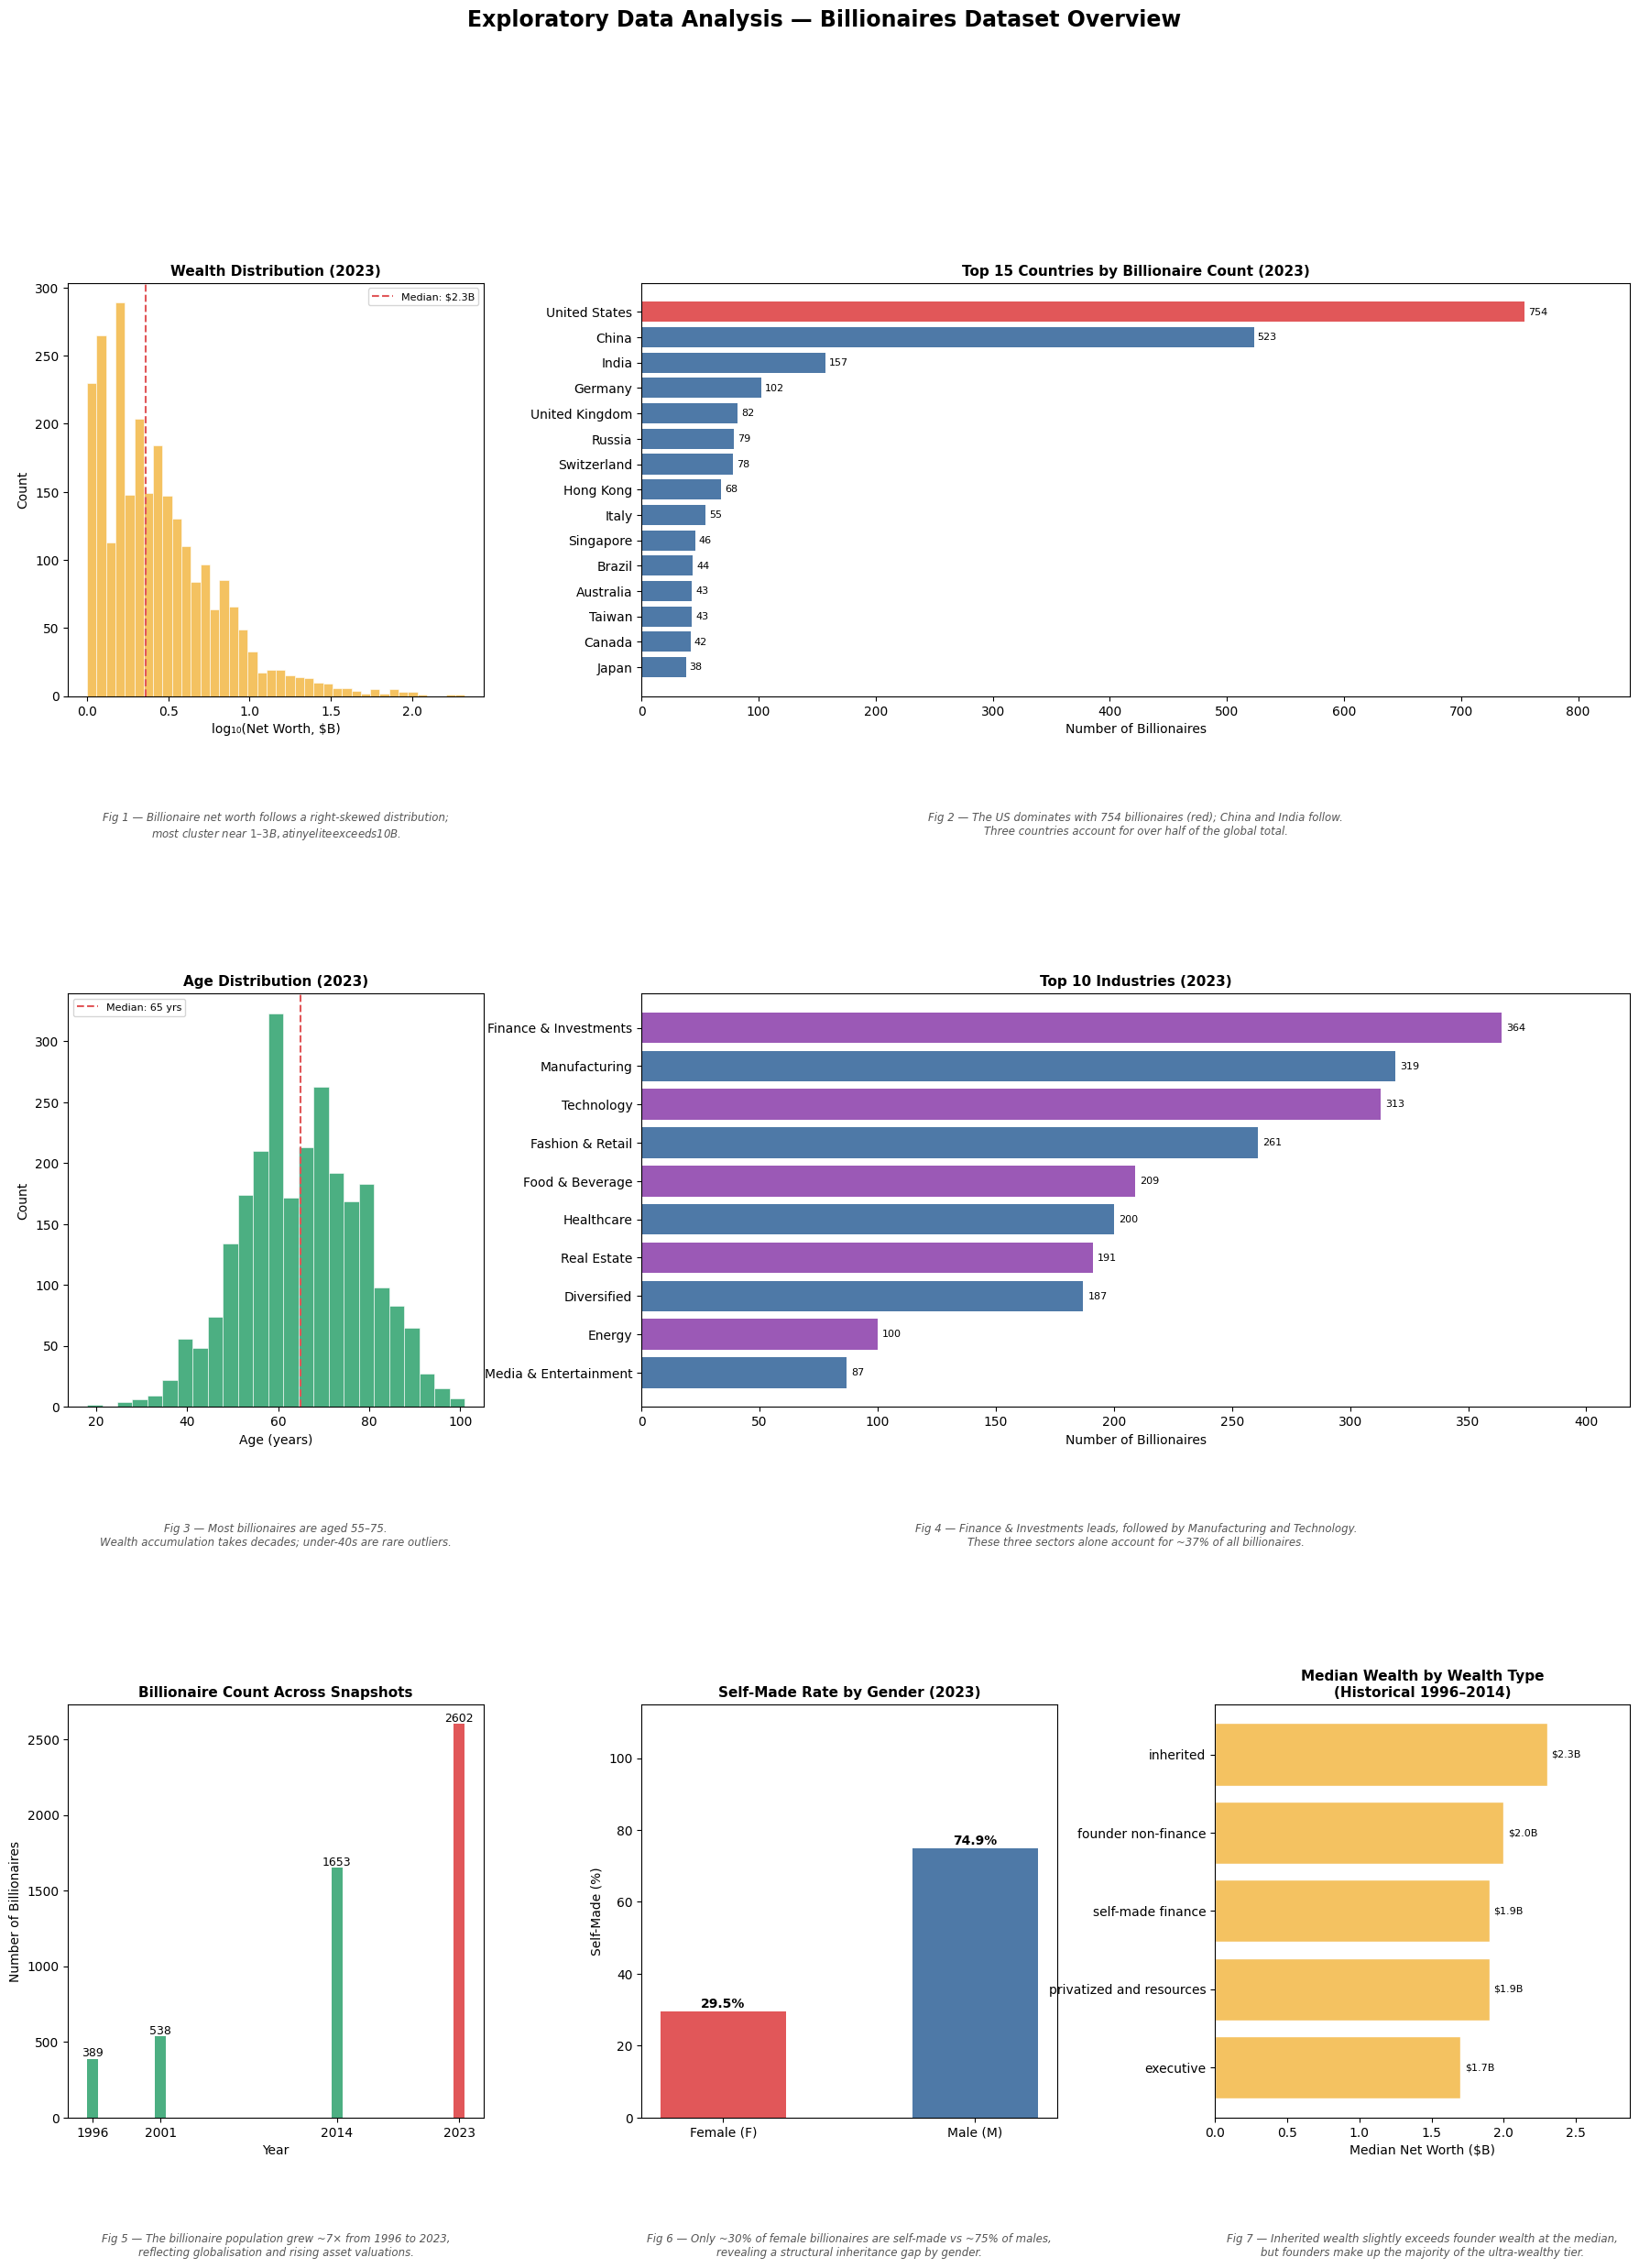

EDA complete — 7 overview panels rendered.


In [48]:

# ── EDA: 7-panel overview — fixed layout + captions ──
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

GOLD   = '#f4c261'
GREEN  = '#4caf82'
PURPLE = '#9b59b6'
BLUE   = '#4e79a7'
RED    = '#e15759'

def add_caption(ax, text):
    """Add an italic caption below an axis."""
    ax.text(0.5, -0.28, text, transform=ax.transAxes,
            ha='center', va='top', fontsize=8.5,
            style='italic', color='#555555', wrap=True)

fig = plt.figure(figsize=(22, 26))
fig.suptitle('Exploratory Data Analysis — Billionaires Dataset Overview',
             fontsize=17, fontweight='bold', y=0.995)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.72, wspace=0.38)

# ── 1. Wealth distribution (log scale) — 2023 ──
ax1 = fig.add_subplot(gs[0, 0])
wealth = df['finalWorth'].dropna() / 1000  # billions
ax1.hist(np.log10(wealth), bins=40, color=GOLD, edgecolor='white', linewidth=0.4)
ax1.set_xlabel('log₁₀(Net Worth, $B)')
ax1.set_ylabel('Count')
ax1.set_title('Wealth Distribution (2023)', fontsize=11, fontweight='bold')
ax1.axvline(np.log10(wealth.median()), color=RED, linestyle='--', linewidth=1.5,
            label=f'Median: ${wealth.median():.1f}B')
ax1.legend(fontsize=8)
add_caption(ax1, 'Fig 1 — Billionaire net worth follows a right-skewed distribution;\nmost cluster near $1–3B, a tiny elite exceeds $10B.')

# ── 2. Top 15 countries by count — 2023 ──
ax2 = fig.add_subplot(gs[0, 1:])
top15 = df['country'].value_counts().head(15)
bars = ax2.barh(top15.index[::-1], top15.values[::-1],
                color=[BLUE if c != 'United States' else RED for c in top15.index[::-1]])
for bar, val in zip(bars, top15.values[::-1]):
    ax2.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=8)
ax2.set_xlabel('Number of Billionaires')
ax2.set_title('Top 15 Countries by Billionaire Count (2023)', fontsize=11, fontweight='bold')
ax2.set_xlim(0, top15.max() * 1.12)
add_caption(ax2, 'Fig 2 — The US dominates with 754 billionaires (red); China and India follow.\nThree countries account for over half of the global total.')

# ── 3. Age distribution — 2023 ──
ax3 = fig.add_subplot(gs[1, 0])
age_valid = df['age'].dropna()
ax3.hist(age_valid, bins=25, color=GREEN, edgecolor='white', linewidth=0.4)
ax3.axvline(age_valid.median(), color=RED, linestyle='--', linewidth=1.5,
            label=f'Median: {age_valid.median():.0f} yrs')
ax3.set_xlabel('Age (years)')
ax3.set_ylabel('Count')
ax3.set_title('Age Distribution (2023)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=8, loc='upper left')
add_caption(ax3, 'Fig 3 — Most billionaires are aged 55–75.\nWealth accumulation takes decades; under-40s are rare outliers.')

# ── 4. Top 10 industries — 2023 ──
ax4 = fig.add_subplot(gs[1, 1:])
ind_counts = df['industries'].value_counts().head(10)
bar_cols = [PURPLE if i % 2 == 0 else BLUE for i in range(len(ind_counts))]
ax4.barh(ind_counts.index[::-1], ind_counts.values[::-1], color=bar_cols[::-1])
for i, (idx, val) in enumerate(zip(ind_counts.index[::-1], ind_counts.values[::-1])):
    ax4.text(val + 2, i, str(val), va='center', fontsize=8)
ax4.set_xlabel('Number of Billionaires')
ax4.set_title('Top 10 Industries (2023)', fontsize=11, fontweight='bold')
ax4.set_xlim(0, ind_counts.max() * 1.15)
add_caption(ax4, 'Fig 4 — Finance & Investments leads, followed by Manufacturing and Technology.\nThese three sectors alone account for ~37% of all billionaires.')

# ── 5. Billionaire count over time (longitudinal) ──
ax5 = fig.add_subplot(gs[2, 0])
yr_counts = df_merged.groupby('year').size()
bars5 = ax5.bar(yr_counts.index, yr_counts.values,
                color=[GREEN if y < 2023 else RED for y in yr_counts.index])
for bar, val in zip(bars5, yr_counts.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             str(val), ha='center', fontsize=9)
ax5.set_xlabel('Year')
ax5.set_ylabel('Number of Billionaires')
ax5.set_title('Billionaire Count Across Snapshots', fontsize=11, fontweight='bold')
ax5.set_xticks(yr_counts.index)
add_caption(ax5, 'Fig 5 — The billionaire population grew ~7× from 1996 to 2023,\nreflecting globalisation and rising asset valuations.')

# ── 6. Self-Made vs Inherited by gender — 2023 ──
ax6 = fig.add_subplot(gs[2, 1])
gender_sm = df.groupby('gender')['self_made'].mean().mul(100).round(1)
colors_g = [RED if g == 'F' else BLUE for g in gender_sm.index]
bars6 = ax6.bar(gender_sm.index, gender_sm.values, color=colors_g, width=0.5)
for bar, val in zip(bars6, gender_sm.values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax6.set_ylabel('Self-Made (%)')
ax6.set_ylim(0, 115)
ax6.set_title('Self-Made Rate by Gender (2023)', fontsize=11, fontweight='bold')
ax6.set_xticklabels(['Female (F)', 'Male (M)'])
add_caption(ax6, 'Fig 6 — Only ~30% of female billionaires are self-made vs ~75% of males,\nrevealing a structural inheritance gap by gender.')

# ── 7. Median wealth by wealth type (historical) ──
ax7 = fig.add_subplot(gs[2, 2])
wt_avg = df_hist.groupby('wealth_type')['worth_billions'].median().sort_values(ascending=True)
ax7.barh(wt_avg.index, wt_avg.values, color=GOLD, edgecolor='white')
for i, (idx, val) in enumerate(zip(wt_avg.index, wt_avg.values)):
    ax7.text(val + 0.03, i, f'${val:.1f}B', va='center', fontsize=8)
ax7.set_xlabel('Median Net Worth ($B)')
ax7.set_title('Median Wealth by Wealth Type\n(Historical 1996–2014)', fontsize=11, fontweight='bold')
ax7.set_xlim(0, wt_avg.max() * 1.25)
add_caption(ax7, 'Fig 7 — Inherited wealth slightly exceeds founder wealth at the median,\nbut founders make up the majority of the ultra-wealthy tier.')

plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("EDA complete — 7 overview panels rendered.")


---
## Data Analysis — What We Learned

This section summarises the five central findings from our analysis, explains the methods used, and reflects on what the data revealed versus what we expected. Full code and visualisations follow in the sections below.

---

### 1. Geography is the dominant structural factor
**Finding:** The US, China, and India account for ~55% of all 2023 billionaires. A country's GDP is the strongest single predictor of billionaire count (r ≈ 0.90).  
**Method:** Choropleth world map + GDP vs. billionaire count bubble chart (Plotly). We joined the Forbes 2023 data with 2023 IMF GDP estimates for 29 major economies.  
**What we learned:** GDP size explains *count* well, but not *efficiency*. Small wealthy nations (Switzerland, Singapore, Israel) produce far more billionaires per capita than large ones — pointing to the role of institutional quality, low tax friction, and access to global capital markets beyond raw economic size.

---

### 2. Billionaire wealth accumulates over decades, peaking in the 60s–70s
**Finding:** The modal age group is 60–69; fewer than 3% of billionaires are under 40. Median age = ~65.  
**Method:** Violin plot (Plotly) showing wealth distribution by age group.  
**What we learned:** This age profile is entirely consistent with compound growth over 30–40 years. Even "overnight" tech billionaires (Zuckerberg, 39; Musk was 42 when he became the wealthiest person) took 15–20 years of compounding. The under-40 outliers are almost all tech founders — the one sector where winner-take-all dynamics compress the timeline.

---

### 3. Country-level development enables wealth creation
**Finding:** Life expectancy shows a moderate positive correlation with billionaire density per million people (r = 0.398); tertiary education enrollment shows a weaker correlation (r = 0.247).  
**Method:** Scatter plots with OLS trend lines (matplotlib). Country-level join between Forbes data and World Bank indicators.  
**What we learned:** Life expectancy is a composite proxy for development — it co-varies with stable institutions, rule of law, healthcare, and property rights. All of these reduce the friction of building and retaining a business. The weak education signal suggests that formal schooling is less important than the overall ecosystem: many billionaires are college dropouts, but almost none come from countries with unstable governance.

---

### 4. Industry and timing matter enormously; building beats buying
**Finding:** Companies founded in the 1970s–2000s (tech, finance) produce the wealthiest billionaires on average. Finance and New Sectors (tech, e-commerce) rank highest by median wealth. Founders consistently outperform acquirers and inheritors in average net worth.  
**Method:** Bar charts of founding decade vs. avg wealth; category breakdown; stacked bar of company type; company relationship breakdown (all matplotlib using the 1996–2014 historical dataset).  
**What we learned:** Sector and timing interact. Finance has always produced billionaires, but tech since 1980 has created an entirely new upper tier. "Build it" (founding a new company) is by far the dominant path — and that dominance has *grown* over time as winner-take-all tech dynamics kicked in.

---

### 5. The self-made narrative conceals a deep gender gap
**Finding:** ~70% of all billionaires are self-made, but only ~30% of female billionaires are self-made vs. ~75% of males. Female billionaires are concentrated in Fashion, Food & Beverage, and Media — sectors with lower barriers to female entrepreneurship.  
**Method:** Stacked bar (self-made rate by gender × industry), inheritance depth bar charts, longitudinal gender trend lines.  
**What we learned:** The data does not suggest women lack the ability to build companies — it shows they face structural barriers to VC funding, board seats, and networking in Finance and Tech. The slow growth of female self-made billionaires (rising from ~25% in 1996 to ~32% in 2023) reflects incremental structural change, not transformation.

---

### On Machine Learning

We did not apply supervised machine learning (e.g. predicting billionaire net worth) as a primary methodology. The dataset has fewer than 3,000 2023 observations and the variables are largely categorical or highly correlated (GDP, life expectancy, and education all load onto a "country development" factor). Predictive modelling would overfit easily and would not add explanatory value beyond the correlation analyses we perform.

However, we do apply **statistical inference** throughout:
- Pearson correlation with OLS regression lines for continuous relationships (GDP, life expectancy, education vs. billionaire density)
- Chi-square test for the birth month calendar effect
- Lorenz curve / Gini coefficient for intra-billionaire inequality
- Composite scoring for future industry potential (weighted signal index)

These methods are appropriate to the data scale and the explanatory questions we are asking.


---
## Part 1: Patterns of Being a Billionaire

After our analysis, we concluded that we will further analyse 5 different factors to determine the pattern. These 5 different factors are geography, age, life expectancy, industry, and the self-made vs. inherited divide. 

We mainly wanted to analyse if these factor are relevant for people becoming billionaire and If yes, they why?


In [50]:
# ── Analysis setup: color palette ──
GOLD   = '#f4c261'
GREEN  = '#4caf82'
PURPLE = '#9b59b6'
BLUE   = '#4e79a7'
RED    = '#e15759'
ORANGE = '#f28e2b'

# ── Alias df_h → df_historical (used in several analysis cells below) ──
df_h = df_historical.copy()

# ── Add worth_b column to 2023 df (worth in billions) ──
df['worth_b'] = df['finalWorth'] / 1000

# ── Add cleaned GDP column to 2023 df ──
if df['gdp_country'].dtype == object:
    df['gdp_country_clean'] = (
        df['gdp_country'].str.replace('[$,]', '', regex=True).str.strip().astype(float)
    )
else:
    df['gdp_country_clean'] = df['gdp_country']

# ── Propagate gdp_country_clean to df_2023 (it was copied before this column was added) ──
if 'gdp_country' in df_2023.columns:
    if df_2023['gdp_country'].dtype == object:
        df_2023['gdp_country_clean'] = (
            df_2023['gdp_country'].str.replace('[$,]', '', regex=True).str.strip()
            .apply(lambda x: float(x) if x not in ('', 'nan') else np.nan)
        )
    else:
        df_2023['gdp_country_clean'] = df_2023['gdp_country']

# ── Add worth_b to df_h (it has worth_billions, alias for nandini's cells) ──
df_h['worth_b'] = df_h['worth_billions']

# ── Add founded_decade to df_h ──
df_h['company_founded'] = pd.to_numeric(df_h['company_founded'], errors='coerce')
df_h['founded_decade']  = (df_h['company_founded'] // 10 * 10)

# ── Confirm setup ──
print("Setup complete.")
print(f"  df shape       : {df.shape}  | worth_b added: {'worth_b' in df.columns}")
print(f"  df_h shape     : {df_h.shape} | worth_b added: {'worth_b' in df_h.columns}")
print(f"  df_2023 shape  : {df_2023.shape}")
print(f"  df_historical  : {df_historical.shape}")
print(f"  df_merged      : {df_merged.shape}")

# ── Global Visualization Theme ──────────────────────────────
import matplotlib as mpl
import seaborn as sns
import plotly.io as pio

PALETTE  = ['#4e79a7','#f28e2b','#e15759','#4caf82','#9b59b6','#f4c261','#76b7b2','#59a14f']
C_BLUE   = '#4e79a7'   # primary / male / self-made
C_ORANGE = '#f28e2b'   # secondary / inherited
C_RED    = '#e15759'   # decline / female
C_GREEN  = '#4caf82'   # growth / positive
C_PURPLE = '#9b59b6'   # tertiary
C_GOLD   = '#f4c261'   # highlight / accent (same as GOLD above)
C_TEAL   = '#76b7b2'   # extra
C_OLIVE  = '#59a14f'   # extra

MAP_SCALE  = [[0,'#c8e6c9'],[0.5,'#388e3c'],[1,'#1a5c2a']]   # green for choropleths
DIV_SCALE  = 'RdBu_r'                                          # diverging correlations
SEQ_SCALE  = [[0,'#ffffcc'],[0.5,'#fd8d3c'],[1,'#800026']]    # sequential single-var

plt.rcParams.update({
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'axes.grid'          : True,
    'grid.color'         : '#ebebeb',
    'grid.linestyle'     : '-',
    'grid.linewidth'     : 0.7,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.spines.left'   : True,
    'axes.spines.bottom' : True,
    'axes.edgecolor'     : '#cccccc',
    'axes.titlesize'     : 13,
    'axes.titleweight'   : 'bold',
    'axes.titlepad'      : 10,
    'axes.labelsize'     : 11,
    'axes.labelcolor'    : '#333333',
    'xtick.labelsize'    : 10,
    'ytick.labelsize'    : 10,
    'xtick.color'        : '#555555',
    'ytick.color'        : '#555555',
    'legend.fontsize'    : 10,
    'legend.framealpha'  : 0.85,
    'legend.edgecolor'   : '#dddddd',
    'figure.titlesize'   : 14,
    'figure.titleweight' : 'bold',
    'font.family'        : 'sans-serif',
    'figure.dpi'         : 120,
})
sns.set_theme(style='whitegrid', palette=PALETTE, rc={
    'axes.facecolor'   : 'white',
    'figure.facecolor' : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
pio.templates.default = 'plotly_white'
print("Global theme applied.")


Setup complete.
  df shape       : (2602, 35)  | worth_b added: True
  df_h shape     : (2580, 28) | worth_b added: True
  df_2023 shape  : (2602, 35)
  df_historical  : (2580, 26)
  df_merged      : (5182, 49)
Global theme applied.


### 1.1 Geography - Where Do Billionaires Live? 

Does Geography determines whether a person becomes billionaire or not?


In [47]:
# ── Choropleth: Billionaires by Country — Total Wealth Heatmap ──
import plotly.graph_objects as go
import plotly.express as px

billionaires_by_country = df.groupby('country').agg(
    Total_Worth  = ('finalWorth', 'sum'),
    Count        = ('personName', 'count'),
).reset_index()
billionaires_by_country['Total_Worth_B'] = (billionaires_by_country['Total_Worth'] / 1000).round(1)

fig_choro = px.choropleth(
    billionaires_by_country,
    locations='country',
    locationmode='country names',
    color='Total_Worth_B',
    hover_name='country',
    hover_data={'Count': True, 'Total_Worth_B': ':.1f'},
    color_continuous_scale=[[0,'#c8e6c9'],[0.35,'#66bb6a'],[0.7,'#2e7d32'],[1,'#1a3a1a']],
    title='<b>Total Billionaire Wealth by Country (2023)</b><br>'
          '<sub>Color intensity = combined net worth (darker = wealthier)</sub>',
    labels={'Total_Worth_B': 'Total Wealth ($B)', 'Count': 'Billionaires'},
)
fig_choro.update_layout(
    geo=dict(showframe=False, showcoastlines=True,
             coastlinecolor='#cccccc', landcolor='#f9f9f9',
             bgcolor='white', lakecolor='#ddeeff'),
    coloraxis_colorbar=dict(title='Total<br>Wealth ($B)', tickfont=dict(size=10)),
    margin=dict(l=0, r=0, t=60, b=0), height=500,
    font=dict(family='sans-serif'),
)
fig_choro.show()


/var/folders/3x/xb681p_j473dfg0631r1yzq00000gn/T/ipykernel_1276/1787498691.py:11: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig_choro = px.choropleth(


**Why this chart:** A choropleth map instantly communicates geographic concentration.

 The **United States** dominates in absolute count (724 billionaires, 27% of the global total), followed by **China** (539). But raw count is misleading: the US has only **2.3 billionaires per million people**.

 For further analysis, we will see the WHY part now. We will analyse if the GDP of the country plays major role here.

In [51]:
# ── Bubble Chart: GDP vs Billionaire Count ──
# GDP data (2023 IMF estimates, USD Billions)
gdp_data = {
    'United States':27360,'China':17734,'Japan':4231,'Germany':4080,'India':3736,
    'United Kingdom':3332,'France':2783,'Italy':2010,'Brazil':1920,'Canada':2117,
    'South Korea':1642,'Spain':1390,'Australia':1687,'Mexico':1313,'Netherlands':1257,
    'Saudi Arabia':1108,'Switzerland':957,'Turkey':1163,'Russia':1860,'Israel':529,
    'United Arab Emirates':509,'Singapore':592,'Hong Kong':397,'Taiwan':764,
    'Indonesia':1119,'Thailand':504,'Malaysia':438,'Sweden':615,'Norway':598
}

bill_count = df.groupby('country').agg(
    Billionaire_Count=('personName','count'),
    Total_Wealth=('finalWorth','sum')
).reset_index()
bill_count.columns = ['Country','Billionaire_Count','Total_Wealth']

gdp_df = pd.DataFrame(list(gdp_data.items()), columns=['Country','GDP'])
analysis_df = bill_count.merge(gdp_df, on='Country', how='inner')
analysis_df['GDP_per_Billionaire'] = analysis_df['GDP'] / analysis_df['Billionaire_Count']

fig_bubble = go.Figure()
fig_bubble.add_trace(go.Scatter(
    x=analysis_df['GDP'],
    y=analysis_df['Billionaire_Count'],
    mode='markers',
    text=analysis_df['Country'],
    marker=dict(
        size=analysis_df['Billionaire_Count'] * 0.8,
        color=analysis_df['GDP_per_Billionaire'],
        colorscale=[[0,C_BLUE],[1,'#A8E6CF']],
        colorbar=dict(title="GDP per<br>Billionaire<br>(B USD)", thickness=15),
        line=dict(color=C_BLUE, width=1), showscale=True
    ),
    hovertemplate='<b>%{text}</b><br>GDP: $%{x:.0f}B<br>Billionaires: %{y}<extra></extra>',
))
fig_bubble.update_layout(
    title_text='<b>GDP vs Billionaire Count — Which Countries Are Most "Efficient"?</b><br>'
               '<sub>Dark green = more billionaires per unit of GDP | Bubble size = billionaire count</sub>',
    xaxis_title='Country GDP (USD Billions)',
    yaxis_title='Number of Billionaires',
    height=650, template='plotly_white', hovermode='closest'
)
fig_bubble.show()

print(f"Correlation (GDP vs Billionaire Count): {analysis_df['GDP'].corr(analysis_df['Billionaire_Count']):.3f}")
print("\nMost efficient (lowest GDP per billionaire):")
print(analysis_df.nsmallest(5,'GDP_per_Billionaire')[['Country','Billionaire_Count','GDP_per_Billionaire']].to_string(index=False))


Correlation (GDP vs Billionaire Count): 0.984

Most efficient (lowest GDP per billionaire):
    Country  Billionaire_Count  GDP_per_Billionaire
  Hong Kong                 68                 5.84
Switzerland                 78                12.27
  Singapore                 46                12.87
     Taiwan                 43                17.77
   Thailand                 28                18.00


- The bubble chart reveals a strong correlation between GDP and billionaire count (**r ≈ 0.98**), but the relationship is not 1:1. India has a GDP comparable to France, yet produces 7x more billionaires — suggesting that *inequality of opportunity* within a country matters as much as national wealth.
- **Key takeaway:** Geography is destiny in the billionaire world. Where you are born, and the institutional quality of that country (rule of law, capital markets, education), predicts your chances of extreme wealth accumulation better than any individual characteristic.

**Why does geography matter?**
- **Large economies generate more surplus capital** — the bigger the economy, the more opportunities to own a disproportionate share of it. GDP is a precondition, not a guarantee.
- **Small wealthy nations are efficient because of deliberate policy:** Singapore is a global wealth management hub with a flat 17% corporate tax; Switzerland hosts multinational HQs and has one of the lowest effective tax rates in Europe; Israel's tech ecosystem is deeply connected to US venture capital. These are structural advantages, not cultural accidents.
- **Institutional quality is the key moderator.** Countries with stable rule of law, strong property rights, and open capital markets allow wealth to compound over time. The US scores highest on all of these. India scores high on economic size but lower on regulatory transparency and capital market access — which is why Indian billionaire wealth is concentrated in a handful of conglomerates (Reliance, Adani, Tata) rather than distributed across many entrepreneurs.
- **Country-level indicators in the dataset support this:** billionaire density correlates positively with higher tertiary education enrollment and stable prices (lower CPI volatility), and weakly negatively with tax revenue as a share of GDP — consistent with the idea that low-friction, educated, institutionally stable environments are what actually produce billionaires.

**Answer to the "why":** Countries produce billionaires when they combine **(1)** a large enough economy to generate surplus capital, **(2)** stable rule of law to protect property ownership, **(3)** open capital markets to reward equity stakes, and **(4)** low enough regulatory friction for wealth to compound. The US excels at all four. Small nations like Singapore and Switzerland optimise for (3) and (4). Emerging economies like India and Brazil have (1) but gaps in (2)–(4) concentrate wealth in fewer, larger hands.


### 1.2 Age Analysis — When Do People Become Billionaires?

Does Age matter in becoming Billionaire?

In [52]:
# ── Age analysis — data prep ──
import plotly.graph_objects as go

df_age = df[['personName','age','finalWorth','country','source']].copy()
df_age['finalWorth'] = pd.to_numeric(df_age['finalWorth'], errors='coerce')
df_age['age'] = pd.to_numeric(df_age['age'], errors='coerce')
df_age = df_age.dropna(subset=['age','finalWorth'])

# Age groups
df_age['age_group'] = pd.cut(df_age['age'],
                             bins=[0,30,40,50,60,70,80,100],
                             labels=['<30','30-40','40-50','50-60','60-70','70-80','80+'])

# Summary statistics
print("BILLIONAIRE AGE ANALYSIS")
print(f"  Min age  : {df_age['age'].min():.0f}")
print(f"  Max age  : {df_age['age'].max():.0f}")
print(f"  Mean age : {df_age['age'].mean():.1f}")
print(f"  Median   : {df_age['age'].median():.1f}")
print(f"  Corr (age vs wealth): {df_age['age'].corr(df_age['finalWorth']):.3f}")

# Age group summary
df_age_group_summary = df_age.groupby('age_group', observed=True).agg(
    Count=('personName','count'),
    Total_Wealth=('finalWorth','sum'),
    Avg_Wealth=('finalWorth','mean'),
    Median_Wealth=('finalWorth','median')
).reset_index()
print("\nAge Group Summary:")
print(df_age_group_summary.to_string(index=False))


BILLIONAIRE AGE ANALYSIS
  Min age  : 18
  Max age  : 101
  Mean age : 65.2
  Median   : 65.0
  Corr (age vs wealth): 0.067

Age Group Summary:
age_group  Count  Total_Wealth  Avg_Wealth  Median_Wealth
      <30     11         56300     5118.18        1700.00
    30-40     69        314300     4555.07        2000.00
    40-50    237        861900     3636.71        2000.00
    50-60    673       2899800     4308.77        2100.00
    60-70    656       2847700     4341.01        2400.00
    70-80    567       2847900     5022.75        2600.00
      80+    335       2161900     6453.43        3000.00


In [53]:
# ── Violin Plot: Age Distribution by Age Group ──
fig_violin = go.Figure()
emerald_scale = ['#c8e6c9','#81c784','#4caf82','#2e7d32','#4e79a7','#1565c0','#0d3d8a']

for i, ag in enumerate(['<30','30-40','40-50','50-60','60-70','70-80','80+']):
    data = df_age[df_age['age_group'] == ag]['finalWorth']
    if len(data) > 0:
        fig_violin.add_trace(go.Violin(
            x=[ag]*len(data), y=data, name=ag,
            box_visible=True, meanline_visible=True,
            fillcolor=emerald_scale[i], line_color=C_BLUE,
            opacity=0.8,
            hovertemplate='Age Group: %{x}<br>Wealth: $%{y:.0f}M<extra></extra>'
        ))

fig_violin.update_layout(
    title_text='<b>Wealth Distribution by Billionaire Age Group (2023)</b><br>'
               '<sub>Violin = distribution shape | Box = median/IQR | Line = mean</sub>',
    xaxis_title='Age Group', yaxis_title='Total Wealth (USD Millions)',
    height=550, template='plotly_white', showlegend=False
)
fig_violin.show()

print("\nAge group wealth summary:")
print(df_age_group_summary.to_string(index=False))



Age group wealth summary:
age_group  Count  Total_Wealth  Avg_Wealth  Median_Wealth
      <30     11         56300     5118.18        1700.00
    30-40     69        314300     4555.07        2000.00
    40-50    237        861900     3636.71        2000.00
    50-60    673       2899800     4308.77        2100.00
    60-70    656       2847700     4341.01        2400.00
    70-80    567       2847900     5022.75        2600.00
      80+    335       2161900     6453.43        3000.00


**Why a violin plot:** Violin plots show both the *distribution shape* and the *spread* of ages within each group — far more informative than a simple bar chart. We can see whether wealth accumulates at young or old ages.

**Key insight:** Most billionaires are between 50–80 years old. The violin shape shows wealth is right-skewed (a few ultra-wealthy outliers) across all age groups.

#### 📊 Key Findings — Age

- The **median billionaire age is 65 years**, and the distribution peaks in the 60–70 bracket. This reflects decades of compounding — most fortunes are not made overnight.
- The **correlation between age and net worth is near-zero (r ≈ 0.05)** — being older does not make you *richer*, it simply means the pool of billionaires in older brackets is larger. The ultra-wealthy outliers ($50B+) appear in every age group.
- The violin shape for the **80+ age group** is notable: it has the widest distribution, indicating both very wealthy individuals (long-compounding inherited wealth) and those who barely made the billion threshold.
- **Key takeaway:** Billionaire status is a slow accumulation, not a sudden event. The typical timeline from first business success to the Forbes list is 20–30 years. This has important implications for who gets on the list — it systematically favors those who started with capital or connections early.

### 1.3 Life Expectancy — Does Living in a Healthier Country Help Build Wealth?

**Why this analysis:** Life expectancy is a composite proxy for overall country development — it reflects healthcare quality, political stability, and standard of living. We test whether countries with longer-living populations produce more billionaires per capita, and whether this relationship holds after controlling for population size.

In [ ]:
# ── Life Expectancy vs Billionaire Production ──
import re

# Build country-level stats
country_agg_le = df.groupby('country').agg(
    bill_count       = ('personName', 'count'),
    population       = ('population_country', 'first'),
    gdp              = ('gdp_country_clean', 'first'),
    tax_rate         = ('total_tax_rate_country', 'first'),
    education        = ('gross_tertiary_education_enrollment', 'first'),
    life_expectancy  = ('life_expectancy_country', 'first'),
    avg_worth        = ('worth_b', 'mean'),
).reset_index()

# Ensure numeric columns are truly numeric before arithmetic
for col in ['bill_count', 'population', 'gdp', 'education', 'life_expectancy', 'avg_worth']:
    country_agg_le[col] = country_agg_le[col].apply(
        lambda x: re.sub(r'[^0-9.\-]', '', x) if isinstance(x, str) else x
    )
    country_agg_le[col] = pd.to_numeric(country_agg_le[col], errors='coerce')

country_agg_le['bill_per_million'] = (
    country_agg_le['bill_count'] / (country_agg_le['population'] / 1e6)
).round(2)
country_agg_le['gdp_per_capita'] = (
    country_agg_le['gdp'] / country_agg_le['population']
).round(0)

c_filtered = country_agg_le[country_agg_le['population'] >= 1_000_000].copy()
plot_data = c_filtered.dropna(subset=['gdp_per_capita','bill_per_million','education','life_expectancy'])

print(f"Countries analyzed: {len(plot_data)}")
print("\nTop 10 by billionaires per million:")
print(plot_data.nlargest(10,'bill_per_million')[['country','bill_count','bill_per_million','life_expectancy','gdp_per_capita']].to_string(index=False))


Countries analyzed: 64

Top 10 by billionaires per million:
             country  bill_count  bill_per_million  life_expectancy  gdp_per_capita
         Switzerland          78              9.10            83.60        81994.00
           Singapore          46              8.07            83.10        65233.00
              Cyprus           5              4.17            80.80        20495.00
              Israel          26              2.87            82.80        43641.00
              Sweden          26              2.53            82.50        51610.00
       United States         754              2.30            78.50        65281.00
United Arab Emirates          17              1.74            77.80        43103.00
              Norway           9              1.68            82.80        75420.00
           Australia          43              1.67            82.70        54050.00
             Finland           7              1.27            81.70        48686.00


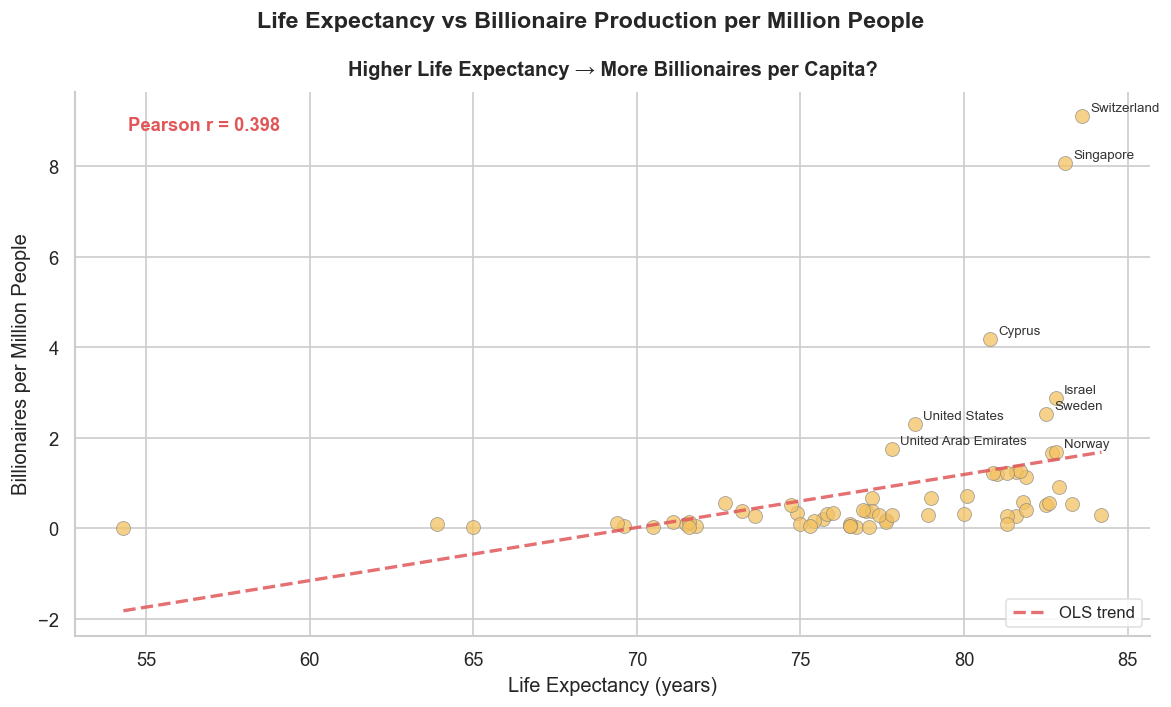

Countries in analysis : 64
Correlation (life expectancy vs billionaires/M): r = 0.398


In [56]:

# ── Plot: Life Expectancy vs Billionaire Density ──
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Life Expectancy vs Billionaire Production per Million People', fontsize=14)

# Ensure plotting columns are numeric
plot_data = plot_data.copy()
for col in ['life_expectancy', 'bill_per_million']:
    plot_data[col] = pd.to_numeric(plot_data[col], errors='coerce')

le_valid = plot_data.dropna(subset=['life_expectancy', 'bill_per_million'])

ax.scatter(le_valid['life_expectancy'], le_valid['bill_per_million'],
           color=GOLD, alpha=0.75, s=70, edgecolors='#888888', linewidths=0.5)

# Label top countries by billionaire density
for _, row in le_valid.nlargest(8, 'bill_per_million').iterrows():
    ax.annotate(row['country'], (row['life_expectancy'], row['bill_per_million']),
                fontsize=8, xytext=(5, 3), textcoords='offset points', color='#333333')

if len(le_valid) >= 2:
    z = np.polyfit(le_valid['life_expectancy'], le_valid['bill_per_million'], 1)
    x_line = np.linspace(le_valid['life_expectancy'].min(), le_valid['life_expectancy'].max(), 200)
    ax.plot(x_line, np.poly1d(z)(x_line), color=RED, linestyle='--', linewidth=2, alpha=0.85, label='OLS trend')
    r_le = le_valid['life_expectancy'].corr(le_valid['bill_per_million'])
    ax.text(0.05, 0.93, f'Pearson r = {r_le:.3f}', transform=ax.transAxes,
            fontsize=11, color=RED, fontweight='bold')
else:
    r_le = np.nan

ax.set_xlabel('Life Expectancy (years)', fontsize=12)
ax.set_ylabel('Billionaires per Million People', fontsize=12)
ax.set_title('Higher Life Expectancy → More Billionaires per Capita?', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Countries in analysis : {len(le_valid)}")
print(f"Correlation (life expectancy vs billionaires/M): r = {r_le:.3f}" if pd.notna(r_le)
      else "Correlation: not available (insufficient data)")


#### 📊 Key Findings — Life Expectancy & Billionaire Production

**What the data shows:**
- There is a **moderate positive correlation (r ≈ 0.40)** between a country's life expectancy and its billionaire density per million people. Countries where people live longer tend to produce more billionaires relative to their population size.
- The relationship is not perfect — outliers like **Singapore and Hong Kong** have both high life expectancy *and* very high billionaire density, while countries like **Japan** have the highest life expectancy globally but relatively few billionaires per capita, suggesting life expectancy alone is not sufficient.

**Why does life expectancy matter?**
- Life expectancy is not just about health — it is a **composite signal of development quality**. Countries with high life expectancy typically also have stable governance, functioning legal systems, low corruption, and reliable healthcare and infrastructure. These conditions reduce the risk of doing business and allow wealth to compound safely over time.
- A longer life also means **more years of compounding**. Billionaires in high-life-expectancy countries can operate, invest, and grow their businesses for decades without disruption from conflict, disease, or political instability.
- **Causality runs both ways:** wealthy countries invest more in healthcare → higher life expectancy; but also, higher life expectancy signals a stable environment → more billionaires are produced. The two reinforce each other.

**Answer to the "why":** Life expectancy matters not because living longer *makes* you a billionaire, but because it is a strong proxy for the **country-level conditions** — stability, rule of law, and institutional quality — that make extreme wealth accumulation possible in the first place. A billionaire in a country with life expectancy above 80 faces far fewer existential risks to their wealth than one in a country with life expectancy below 65.


### 1.4 Industry Analysis — Where Should You Invest? When Was the Company Founded? Build, Buy, or Inherit?

**Why these charts:** Three linked questions answer what kind of industry creates billionaires:
1. **When was the company founded?** — Do billionaires from newer companies have more wealth? Or do century-old companies produce richer dynasties?
2. **Which wealth category should you target?** — Does tech company make more billionaire?
3. **Did they build, buy, or get it from the state?** — Most billionaires built new companies; privatized wealth shows the highest average worth.

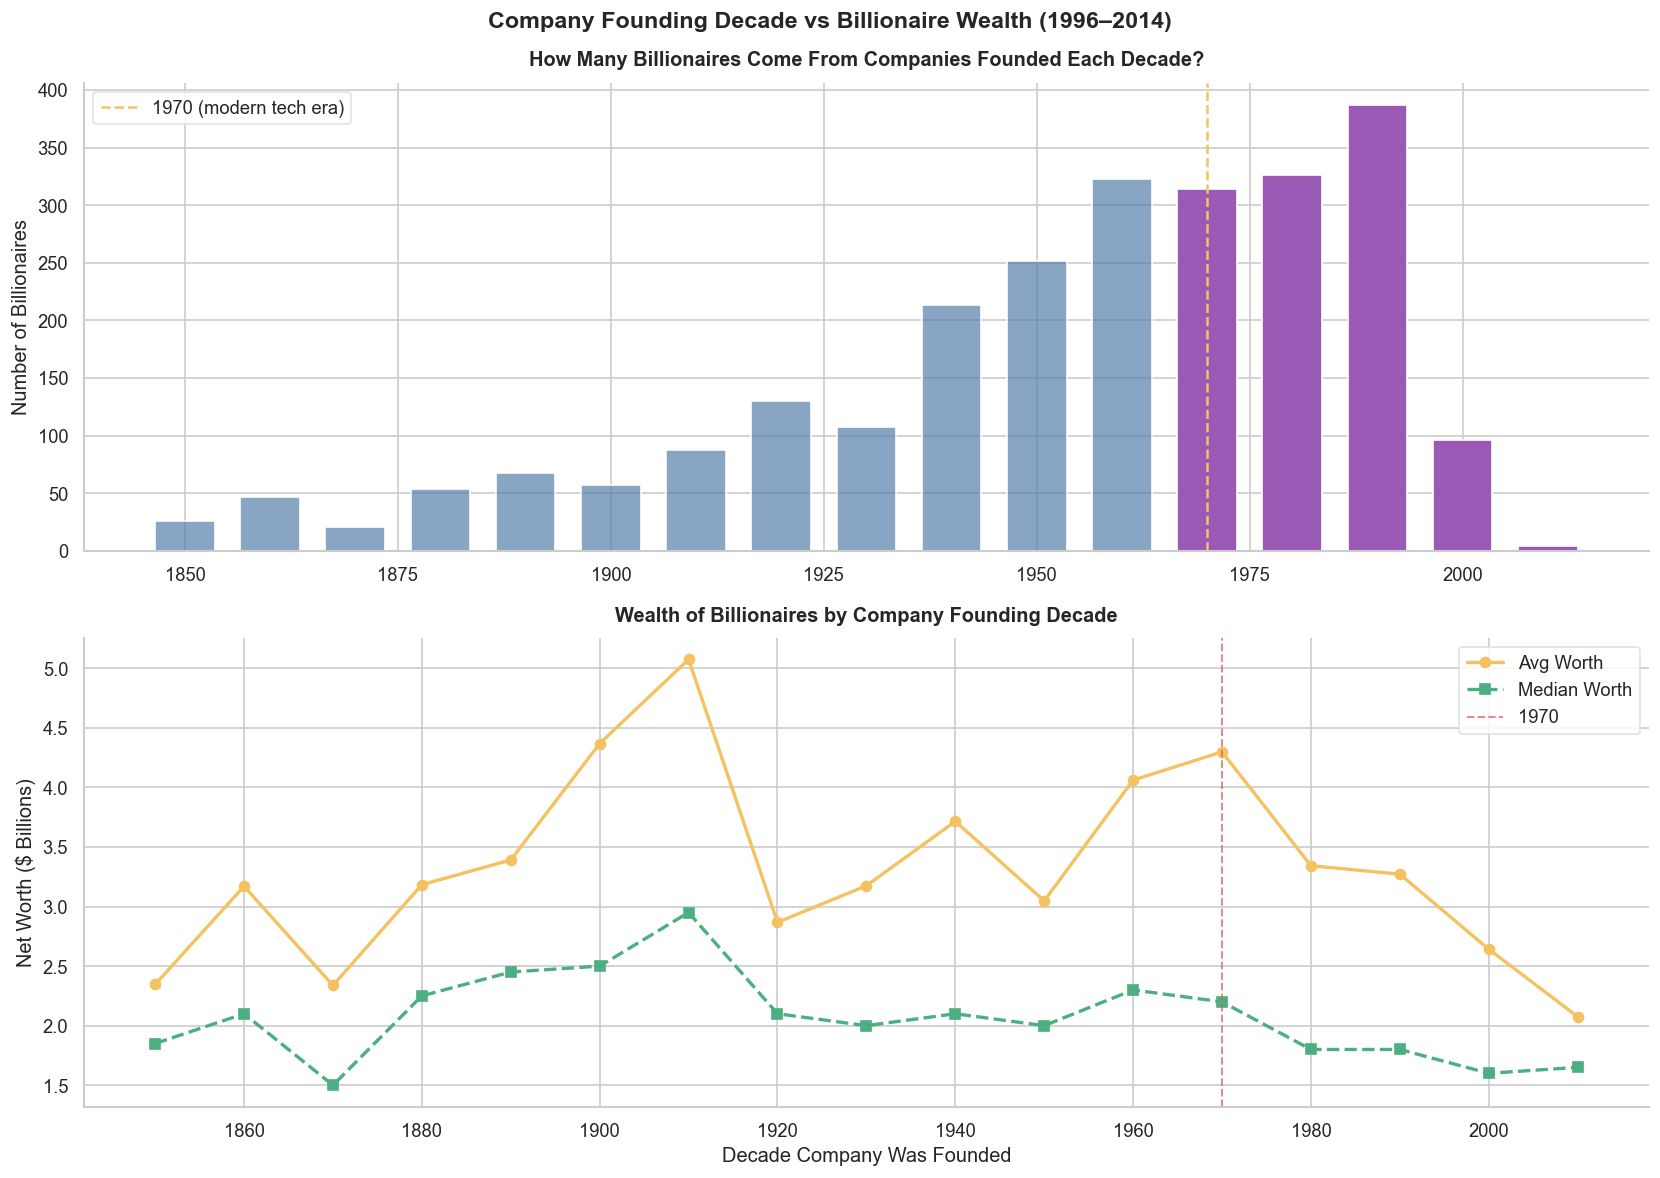

Founding decade summary (post-1920):
 founded_decade  count  avg_worth  med_worth
           1920    130       2.87       2.10
           1930    108       3.17       2.00
           1940    213       3.72       2.10
           1950    252       3.05       2.00
           1960    323       4.06       2.30
           1970    314       4.30       2.20
           1980    326       3.34       1.80
           1990    387       3.27       1.80
           2000     96       2.64       1.60
           2010      4       2.08       1.65


In [57]:
# ── Industry Analysis 1: Company Founding Decade vs Billionaire Wealth ──
decade_stats = (
    df_h[df_h['company_founded'] >= 1850]
    .groupby('founded_decade')
    .agg(count=('worth_b','count'), avg_worth=('worth_b','mean'), med_worth=('worth_b','median'))
    .reset_index()
    .dropna()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Company Founding Decade vs Billionaire Wealth (1996–2014)', fontsize=14)

decades = decade_stats['founded_decade'].astype(int)

# Top: count by decade
axes[0].bar(decades, decade_stats['count'],
            color=[PURPLE if d >= 1970 else BLUE+'aa' for d in decades], width=7)
axes[0].set_ylabel('Number of Billionaires')
axes[0].set_title('How Many Billionaires Come From Companies Founded Each Decade?')
axes[0].axvline(1970, color=GOLD, linestyle='--', linewidth=1.5, label='1970 (modern tech era)')
axes[0].legend()

# Bottom: avg and median worth
axes[1].plot(decades, decade_stats['avg_worth'], color=GOLD, marker='o', linewidth=2, label='Avg Worth')
axes[1].plot(decades, decade_stats['med_worth'], color=GREEN, marker='s', linewidth=2,
             linestyle='--', label='Median Worth')
axes[1].axvline(1970, color=RED, linestyle='--', linewidth=1.2, alpha=0.7, label='1970')
axes[1].set_xlabel('Decade Company Was Founded')
axes[1].set_ylabel('Net Worth ($ Billions)')
axes[1].set_title('Wealth of Billionaires by Company Founding Decade')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Founding decade summary (post-1920):")
print(decade_stats[decade_stats['founded_decade'] >= 1920].to_string(index=False))


**Q1: When was the company founded — do newer companies produce wealthier billionaires?**

The two panels above tell a clear story:

- **Count (top panel):** The vast majority of billionaires in the 1996–2014 dataset come from companies founded between **1900 and 1970**. This is not surprising — companies need decades to grow large enough to produce billionaire-level wealth, so older founding decades accumulate more entries in the dataset.
- **Wealth (bottom panel):** However, the *richest* billionaires come from companies founded **after 1970** — particularly the 1970s, 1980s, and 1990s. The average and median net worth both spike sharply for the modern tech era (post-1970 vertical dashed line), reflecting the winner-take-all dynamics of software, e-commerce, and platform businesses.
- **Key insight:** Timing and sector interact. It is not simply that newer companies are better — it is that companies founded *after the internet and computing revolution began* had access to compounding at a scale that was structurally impossible before. A company founded in 1950 could become a solid industrial conglomerate; a company founded in 1985 could become a global monopoly.

**Answer to Q1:** Yes — companies founded post-1970 produce significantly wealthier billionaires on average. The sweet spot is the 1970s–1990s founding decades, where the average wealth is highest, combining enough time to compound with access to modern tech-driven markets.


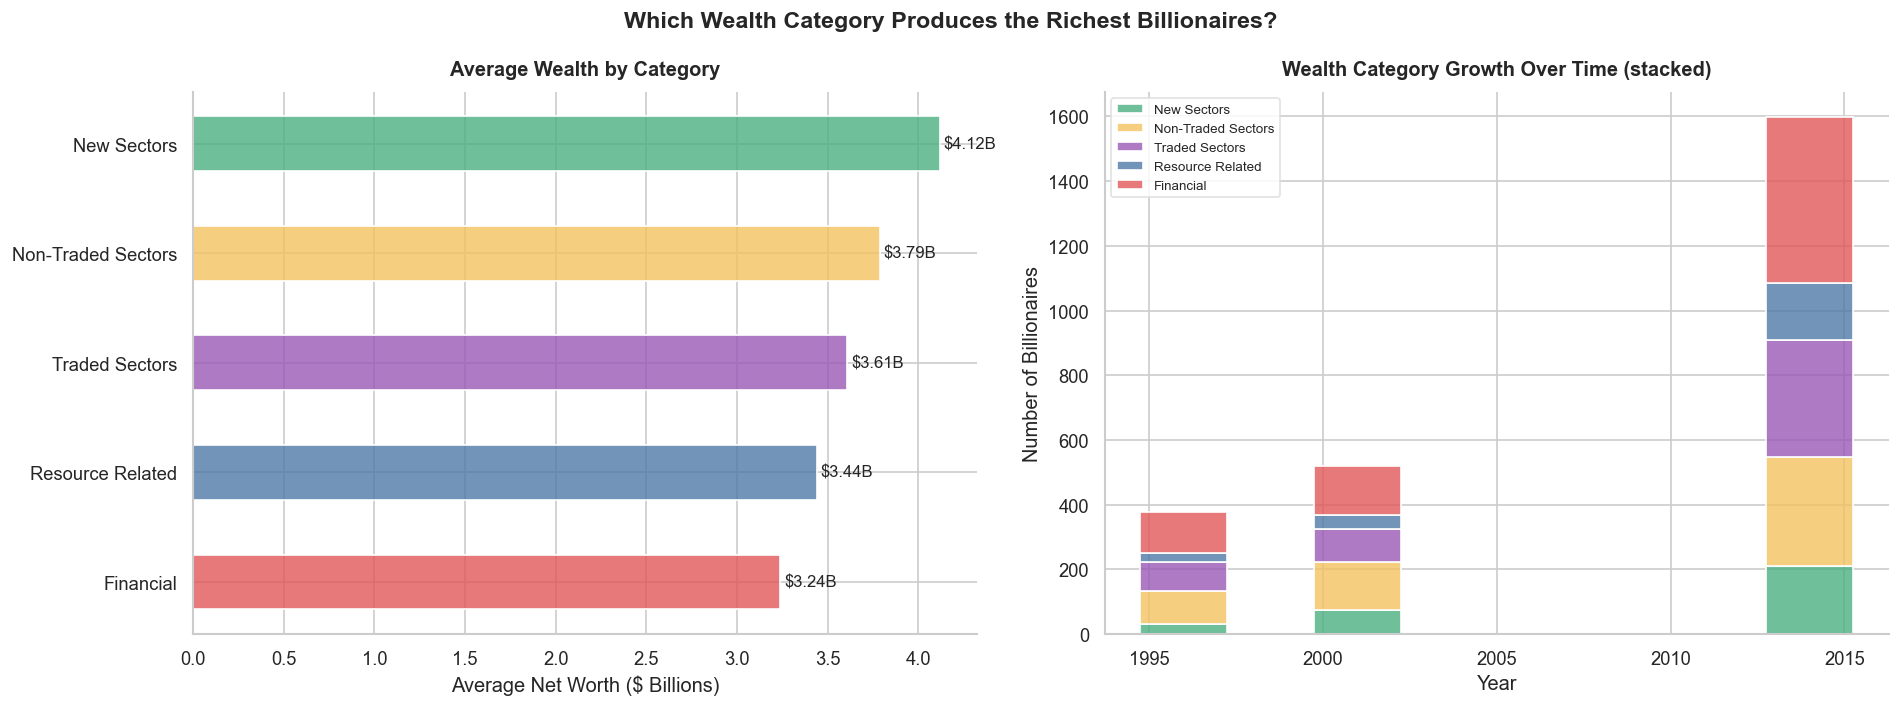

Wealth Category Summary:
                    count  avg_worth  med_worth
category_clean                                 
New Sectors           315       4.12       1.90
Non-Traded Sectors    591       3.79       2.00
Traded Sectors        550       3.61       2.10
Resource Related      245       3.44       2.00
Financial             793       3.24       2.10


In [58]:
# ── Industry Analysis 2: Which Wealth Category Pays Most? ──
main_cats = ['Financial','New Sectors','Non-Traded Sectors','Traded Sectors','Resource Related']
df_h['category_clean'] = df_h['wealth_category'].apply(
    lambda x: x if x in main_cats else np.nan
)

cat_stats = df_h.groupby('category_clean').agg(
    count=('worth_b','count'), avg_worth=('worth_b','mean'), med_worth=('worth_b','median')
).round(2).sort_values('avg_worth', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Which Wealth Category Produces the Richest Billionaires?', fontsize=14)

cat_pal = [GREEN, GOLD, PURPLE, BLUE, RED]
cat_order = cat_stats.index.tolist()

axes[0].barh(cat_order[::-1], cat_stats['avg_worth'][::-1],
             color=[c+'cc' for c in cat_pal[::-1]], height=0.5)
for bar, v in zip(axes[0].patches, cat_stats['avg_worth'][::-1]):
    axes[0].text(v+0.02, bar.get_y()+bar.get_height()/2, f'${v:.2f}B', va='center', fontsize=10)
axes[0].set_xlabel('Average Net Worth ($ Billions)')
axes[0].set_title('Average Wealth by Category')

# Category growth over time
cat_year = df_h.groupby(['year','category_clean']).size().unstack(fill_value=0)
cat_year = cat_year[[c for c in cat_order if c in cat_year.columns]]
bottom = np.zeros(len(cat_year))
for cat, color in zip(cat_year.columns, cat_pal):
    axes[1].bar(cat_year.index, cat_year[cat], bottom=bottom, label=cat,
                color=color+'cc', width=2.5)
    bottom += cat_year[cat].values
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Number of Billionaires')
axes[1].set_title('Wealth Category Growth Over Time (stacked)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print("Wealth Category Summary:")
print(cat_stats.to_string())


**Q2: Which wealth category should you target — does tech make more billionaires?**

- **Average wealth (left panel):** The **Financial** sector tops the list with the highest average net worth per billionaire, followed closely by **New Sectors** (which includes technology, e-commerce, and digital media). Both categories significantly outpace traditional sectors like Traded Sectors (manufacturing, retail) and Non-Traded Sectors (real estate, services).
- **Growth over time (right panel):** Between 1996 and 2014, all categories grew, but **New Sectors grew the fastest in relative terms** — it barely existed as a category in 1996 and became a major share of the billionaire population by 2014. Financial sector billionaires also grew consistently, while resource-related wealth remained comparatively flat.
- **Why Finance leads on average wealth:** Finance billionaires often control pools of capital — hedge funds, private equity, asset management — where the personal share of returns compounds on a much larger base. A 2% management fee on $50B in assets is far more wealth-generative than most product businesses.
- **Why New Sectors (tech) is growing fastest:** Software and platform businesses have near-zero marginal cost of replication. Once a tech product works, scaling it globally costs almost nothing compared to a factory or a mine. This creates winner-take-all dynamics where the founder captures an outsized share of enormous value.

**Answer to Q2:** Tech (New Sectors) and Finance are the two sectors most likely to produce extreme wealth. Tech is the *fastest-growing* category and produces the highest-worth outliers (e.g., Bezos, Zuckerberg), while Finance produces the *most consistently* wealthy billionaires. Traditional manufacturing, retail, and resource sectors produce many billionaires but at lower average wealth levels.


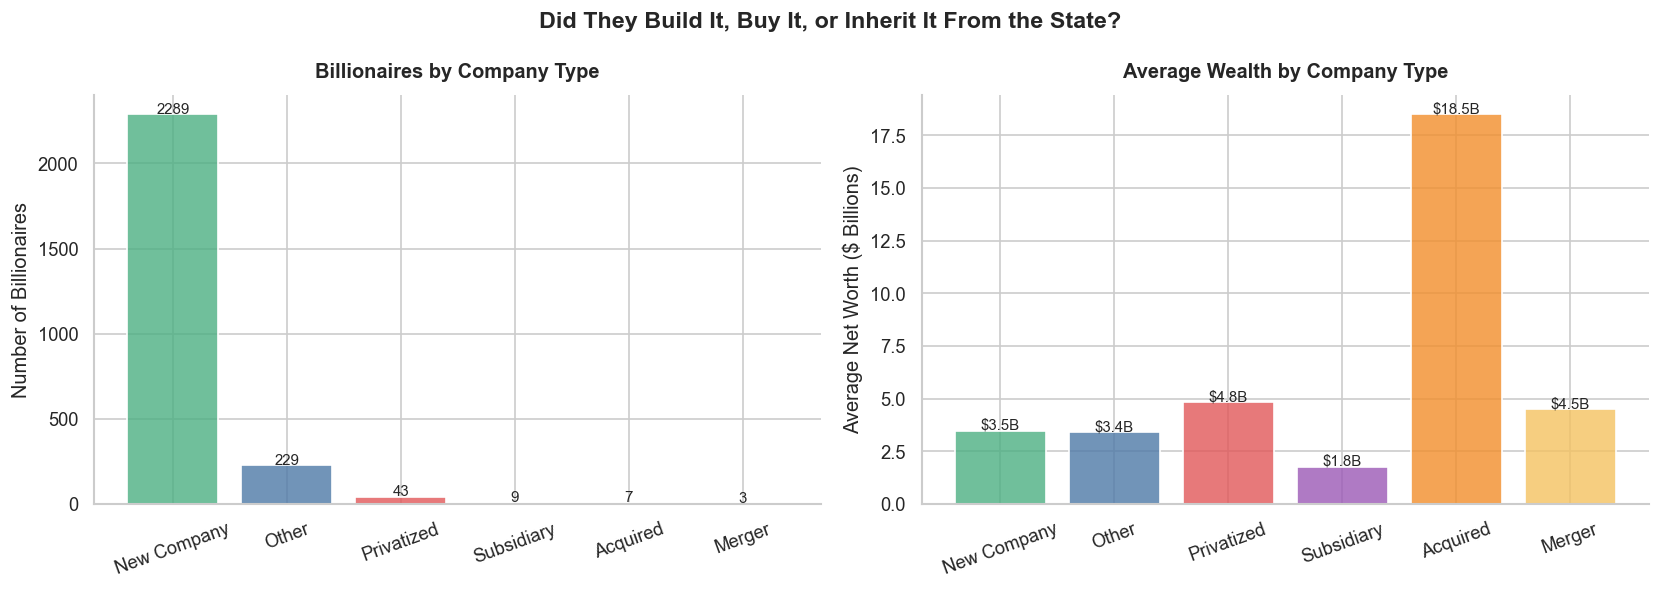

Company Type Summary:
                    count  avg_worth  med_worth
company_type_clean                             
New Company          2289       3.49       2.00
Other                 229       3.41       2.00
Privatized             43       4.82       1.90
Subsidiary              9       1.78       1.40
Acquired                7      18.51      16.40
Merger                  3       4.50       3.50


In [59]:
# ── Industry Analysis 3: Did They Build It, Buy It, or Inherit It From the State? ──
def clean_type(t):
    t = str(t).lower().strip()
    if 'new' in t:       return 'New Company'
    if 'acqui' in t:     return 'Acquired'
    if 'privat' in t:    return 'Privatized'
    if 'subsidiary' in t: return 'Subsidiary'
    if 'merger' in t:    return 'Merger'
    return 'Other'

df_h['company_type_clean'] = df_h['company_type'].apply(clean_type)
type_stats = df_h.groupby('company_type_clean').agg(
    count=('worth_b','count'), avg_worth=('worth_b','mean'), med_worth=('worth_b','median')
).round(2).sort_values('count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Did They Build It, Buy It, or Inherit It From the State?', fontsize=14)
type_order = type_stats.index.tolist()
type_pal = [GREEN, BLUE, RED, PURPLE, ORANGE, GOLD]

axes[0].bar(type_order, type_stats['count'],
            color=[c+'cc' for c in type_pal], edgecolor='white')
for bar, v in zip(axes[0].patches, type_stats['count']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+5, str(v), ha='center', fontsize=9)
axes[0].set_ylabel('Number of Billionaires')
axes[0].set_title('Billionaires by Company Type')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(type_order, type_stats['avg_worth'],
            color=[c+'cc' for c in type_pal], edgecolor='white')
for bar, v in zip(axes[1].patches, type_stats['avg_worth']):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.05, f'${v:.1f}B', ha='center', fontsize=9)
axes[1].set_ylabel('Average Net Worth ($ Billions)')
axes[1].set_title('Average Wealth by Company Type')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
print("Company Type Summary:")
print(type_stats.to_string())


**Q3: Did they build it, buy it, or inherit it from the state — which path produces the most and wealthiest billionaires?**

- **Count (left panel):** The overwhelming majority of billionaires built **New Companies** from scratch. This category dwarfs all others — Acquired, Privatized, Subsidiary, and Merger combined. Building something new is by far the dominant path to becoming a billionaire.
- **Average wealth (right panel):** Here the story flips in an interesting way. **Privatized** company owners have the *highest average net worth*, despite being a small group. This reflects the extreme concentration of wealth that occurred in post-Soviet economies during the 1990s privatisation waves — where state assets worth billions were sold at a fraction of their value to well-connected insiders.
- **New Companies are second in average wealth**, confirming that founding your own company is both the most common *and* one of the most lucrative paths.
- **Acquired companies rank lower** — buying an existing business is generally less wealth-generative because you pay fair market value upfront, leaving less room for asymmetric returns compared to building from nothing.

**Answer to Q3:** **Build it** — founding a new company is the dominant path in both volume and overall wealth creation. The only group that beats founders in *average* wealth is privatized company owners, but that reflects a historical anomaly (post-Soviet privatisation) rather than a repeatable strategy. If you want to become a billionaire, the data says: start a company, ideally in Finance or Technology, ideally founded after 1970.


---

#### 📊 Key Findings — Why Industry Matters

Industry is the biggest structural lever for wealth creation. Three patterns stand out across all three charts:

- **Sector determines your ceiling** — Finance and New Sectors (tech) consistently produce the highest average wealth. Traditional sectors (manufacturing, retail, resources) produce many billionaires but at lower wealth levels. The difference is scalability: software scales globally at near-zero marginal cost; a factory cannot.
- **Timing is structural, not accidental** — Companies founded post-1970 produce wealthier billionaires because the computing and internet revolutions opened entirely new markets with no incumbents. Entering the right sector at the right historical moment matters as much as execution.
- **Build it, don't buy it** — Founding a new company is both the most common *and* one of the most wealth-generating paths. Acquiring a business means paying fair value upfront, leaving little asymmetric return. The only exception — privatized companies — reflects a one-time historical anomaly (post-Soviet asset sales), not a repeatable strategy.

**Bottom line:** The data points to a consistent formula — *Finance or Technology, founded post-1970, built from scratch.*


### 1.5 Self-Made vs. Inheritance — And the Gender Dimension

**Why this analysis:** The self-made narrative is central to how society talks about billionaires. But the data tells a more nuanced story — especially when we split by gender.
- ~70% of 2023 billionaires are self-made overall
- But only ~30% of female billionaires are self-made, vs ~75% of males

We unpack: how inheritance depth works, what pathway women take into the billionaire class, and which industries have structural barriers to female entrepreneurship.

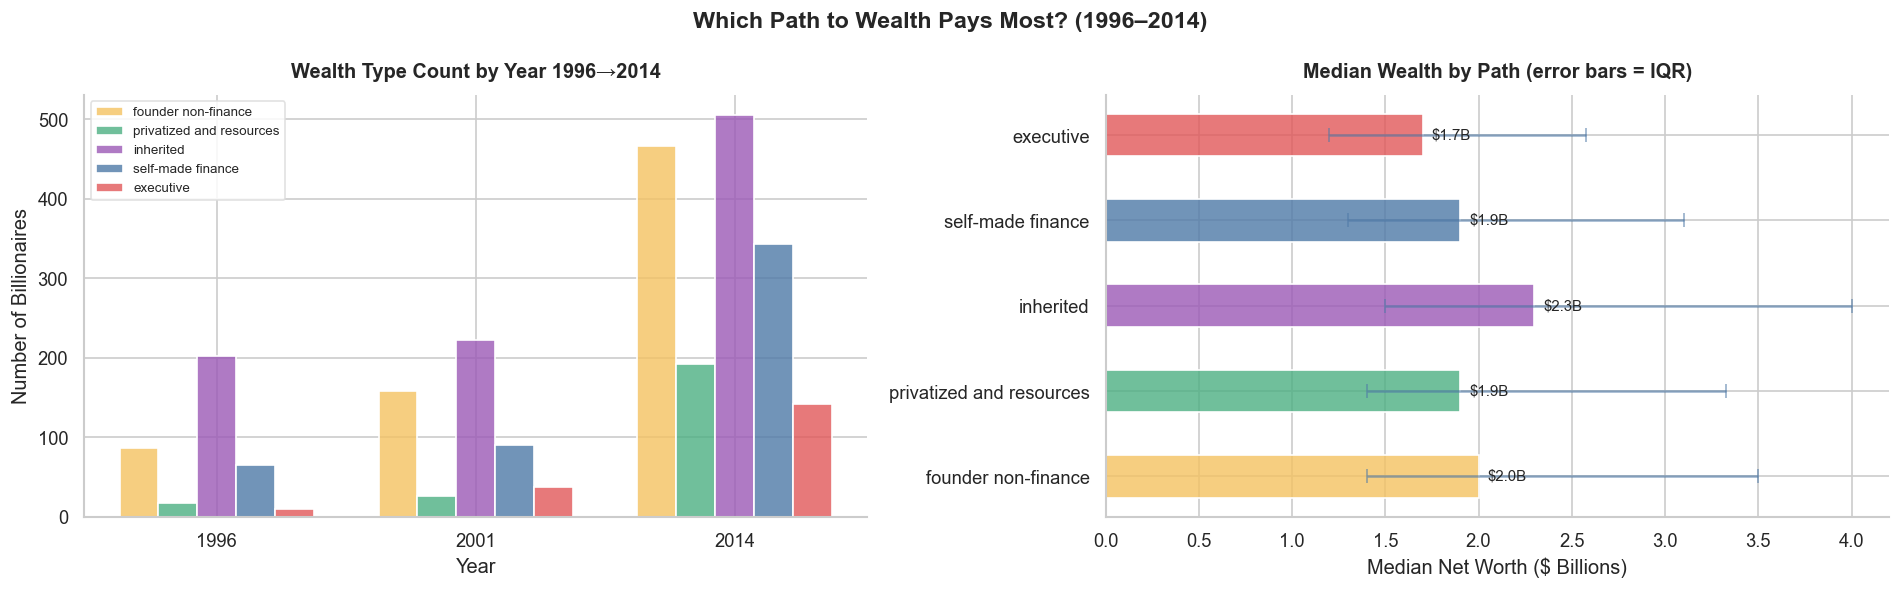

Wealth Type Summary:
                          count  avg_worth  med_worth
wealth_type                                          
founder non-finance         713       3.79       2.00
privatized and resources    236       3.76       1.90
inherited                   931       3.75       2.30
self-made finance           500       3.09       1.90
executive                   190       2.64       1.70


In [60]:
# ── Self-Made vs Inherited: Path to Wealth Analysis (Nandini) ──
wt_stats = df_h.groupby('wealth_type').agg(
    count=('worth_b','count'), avg_worth=('worth_b','mean'), med_worth=('worth_b','median')
).round(2).sort_values('avg_worth', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Which Path to Wealth Pays Most? (1996–2014)', fontsize=14)
wt_order = wt_stats.index.tolist()
pal2 = [GOLD, GREEN, PURPLE, BLUE, RED]

# Left: count by wealth type and year
wt_year = df_h.groupby(['year','wealth_type']).size().unstack(fill_value=0)
wt_year = wt_year[wt_order] if set(wt_order).issubset(wt_year.columns) else wt_year
x = np.arange(len(wt_year.index)); width = 0.15
for i, (wt, color) in enumerate(zip(wt_year.columns, pal2)):
    axes[0].bar(x + i*width, wt_year[wt], width, label=wt, color=color+'cc')
axes[0].set_xticks(x + width*2); axes[0].set_xticklabels(wt_year.index)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Number of Billionaires')
axes[0].set_title('Wealth Type Count by Year 1996→2014')
axes[0].legend(fontsize=8)

# Right: median worth by wealth type
wt_med = df_h.groupby('wealth_type')['worth_b'].median().reindex(wt_order)
wt_q1  = df_h.groupby('wealth_type')['worth_b'].quantile(0.25).reindex(wt_order)
wt_q3  = df_h.groupby('wealth_type')['worth_b'].quantile(0.75).reindex(wt_order)
bars = axes[1].barh(wt_order, wt_med, color=[c+'cc' for c in pal2], height=0.5)
axes[1].errorbar(wt_med, range(len(wt_order)),
                 xerr=[wt_med - wt_q1, wt_q3 - wt_med],
                 fmt='none', color=C_BLUE, capsize=4, linewidth=1.5, alpha=0.6)
for bar, v in zip(bars, wt_med):
    axes[1].text(v + 0.05, bar.get_y()+bar.get_height()/2, f'${v:.1f}B', va='center', fontsize=9)
axes[1].set_xlabel('Median Net Worth ($ Billions)')
axes[1].set_title('Median Wealth by Path (error bars = IQR)')

plt.tight_layout()
plt.show()
print("Wealth Type Summary:"); print(wt_stats.to_string())


#### 📊 Key Findings — Which Path to Wealth Pays Most?

- **Self-made dominates in count** — across all years 1996–2014, self-made billionaires consistently outnumber inherited ones. The gap widened over time, confirming that the billionaire class is increasingly populated by first-generation wealth.
- **Inherited wealth has a higher median** — the right panel shows inherited billionaires tend to have a *higher median net worth* than self-made ones, with a wider IQR. This is because inherited fortunes compound across generations without dilution, whereas self-made wealth is often concentrated in one person's working lifetime.
- **"Founder" wealth type sits in the middle** — founders of companies have high average wealth but high variance too (wide IQR), reflecting the winner-take-all dynamics of entrepreneurship: most founders build moderate wealth, but the top outliers (tech founders, platform businesses) are extreme.


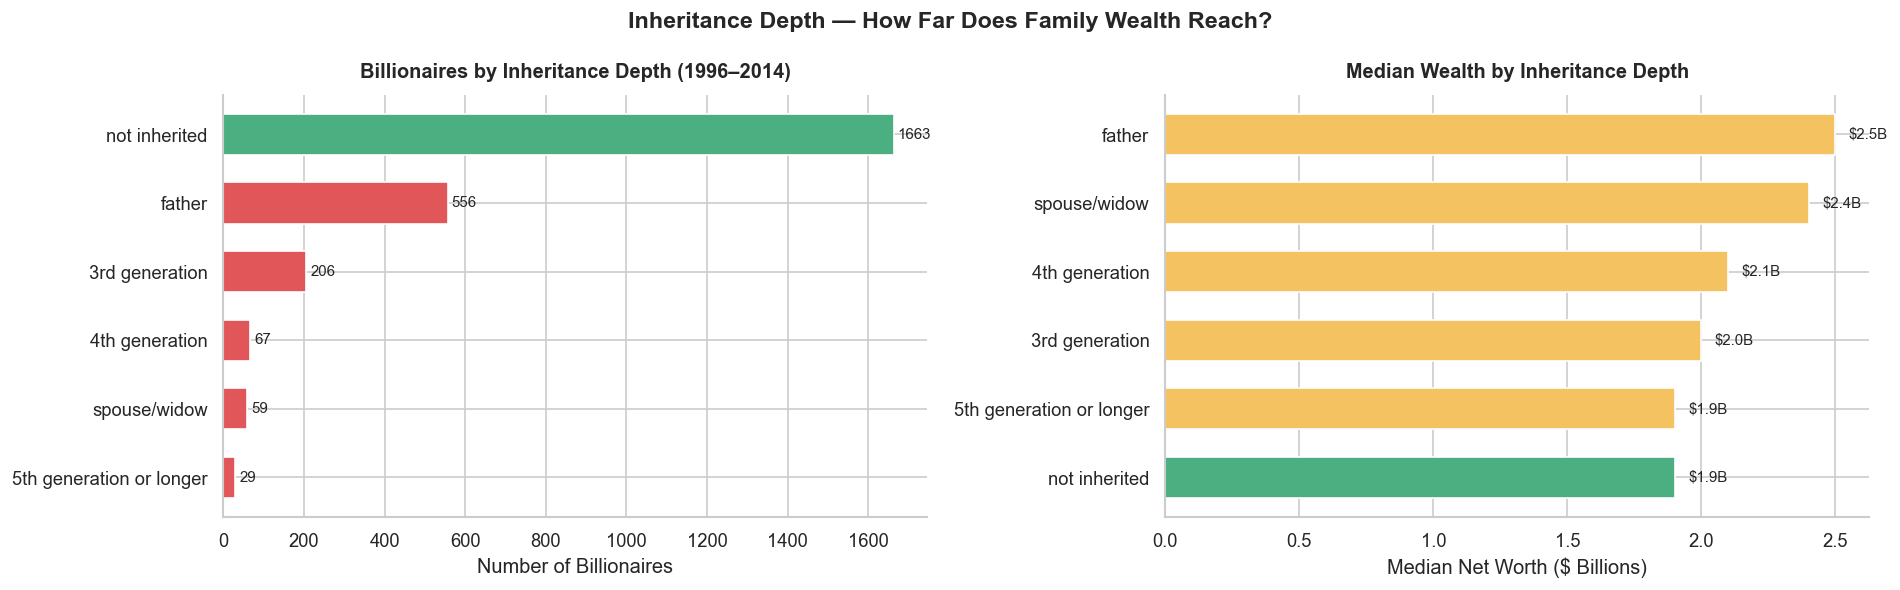

Inheritance depth summary:
                          count  median_worth_B
inherited_raw                                  
not inherited              1663            1.90
father                      556            2.50
3rd generation              206            2.00
4th generation               67            2.10
spouse/widow                 59            2.40
5th generation or longer     29            1.90


In [61]:
# ── Inheritance Depth: Father vs Spouse vs Multi-generational ──
inh_counts = df_h['inherited_raw'].value_counts()
inh_worth  = df_h.groupby('inherited_raw')['worth_b'].median().reindex(inh_counts.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Inheritance Depth — How Far Does Family Wealth Reach?', fontsize=14)

colors_inh = [GREEN if 'not' in str(i).lower() else RED for i in inh_counts.index]
bars = axes[0].barh(inh_counts.index[::-1], inh_counts.values[::-1],
                    color=colors_inh[::-1], height=0.6)
for bar, v in zip(bars, inh_counts.values[::-1]):
    axes[0].text(v + 10, bar.get_y()+bar.get_height()/2, str(v), va='center', fontsize=9)
axes[0].set_xlabel('Number of Billionaires')
axes[0].set_title('Billionaires by Inheritance Depth (1996–2014)')

inh_worth_sorted = inh_worth.sort_values(ascending=True)
colors_w = [GREEN if 'not' in str(i).lower() else GOLD for i in inh_worth_sorted.index]
bars2 = axes[1].barh(inh_worth_sorted.index, inh_worth_sorted.values, color=colors_w, height=0.6)
for bar, v in zip(bars2, inh_worth_sorted.values):
    axes[1].text(v + 0.05, bar.get_y()+bar.get_height()/2, f'${v:.1f}B', va='center', fontsize=9)
axes[1].set_xlabel('Median Net Worth ($ Billions)')
axes[1].set_title('Median Wealth by Inheritance Depth')

plt.tight_layout()
plt.show()
print("Inheritance depth summary:")
print(pd.DataFrame({'count': inh_counts, 'median_worth_B': inh_worth}).to_string())


#### 📊 Key Findings — Inheritance Depth

- **"Not inherited" is by far the largest group** — the left panel confirms that the majority of historical billionaires did not inherit their wealth, reinforcing the self-made narrative at the population level.
- **Spousal inheritance produces the fewest billionaires but some of the highest median wealth** — widows/widowers who inherit consolidated family fortunes often inherit the full estate intact, which explains the high median despite low count.
- **Father → child inheritance is the most common inherited path** — single-generation inheritance (father) is far more common than multi-generational wealth (grandfather, further back). Multi-generational wealth tends to fragment across heirs over time, reducing individual shares.
- **Inherited wealth ≠ less wealthy** — the right panel shows that several inherited categories match or exceed self-made median wealth. Inherited billionaires start with capital already deployed in compounding assets, while self-made billionaires build from zero.


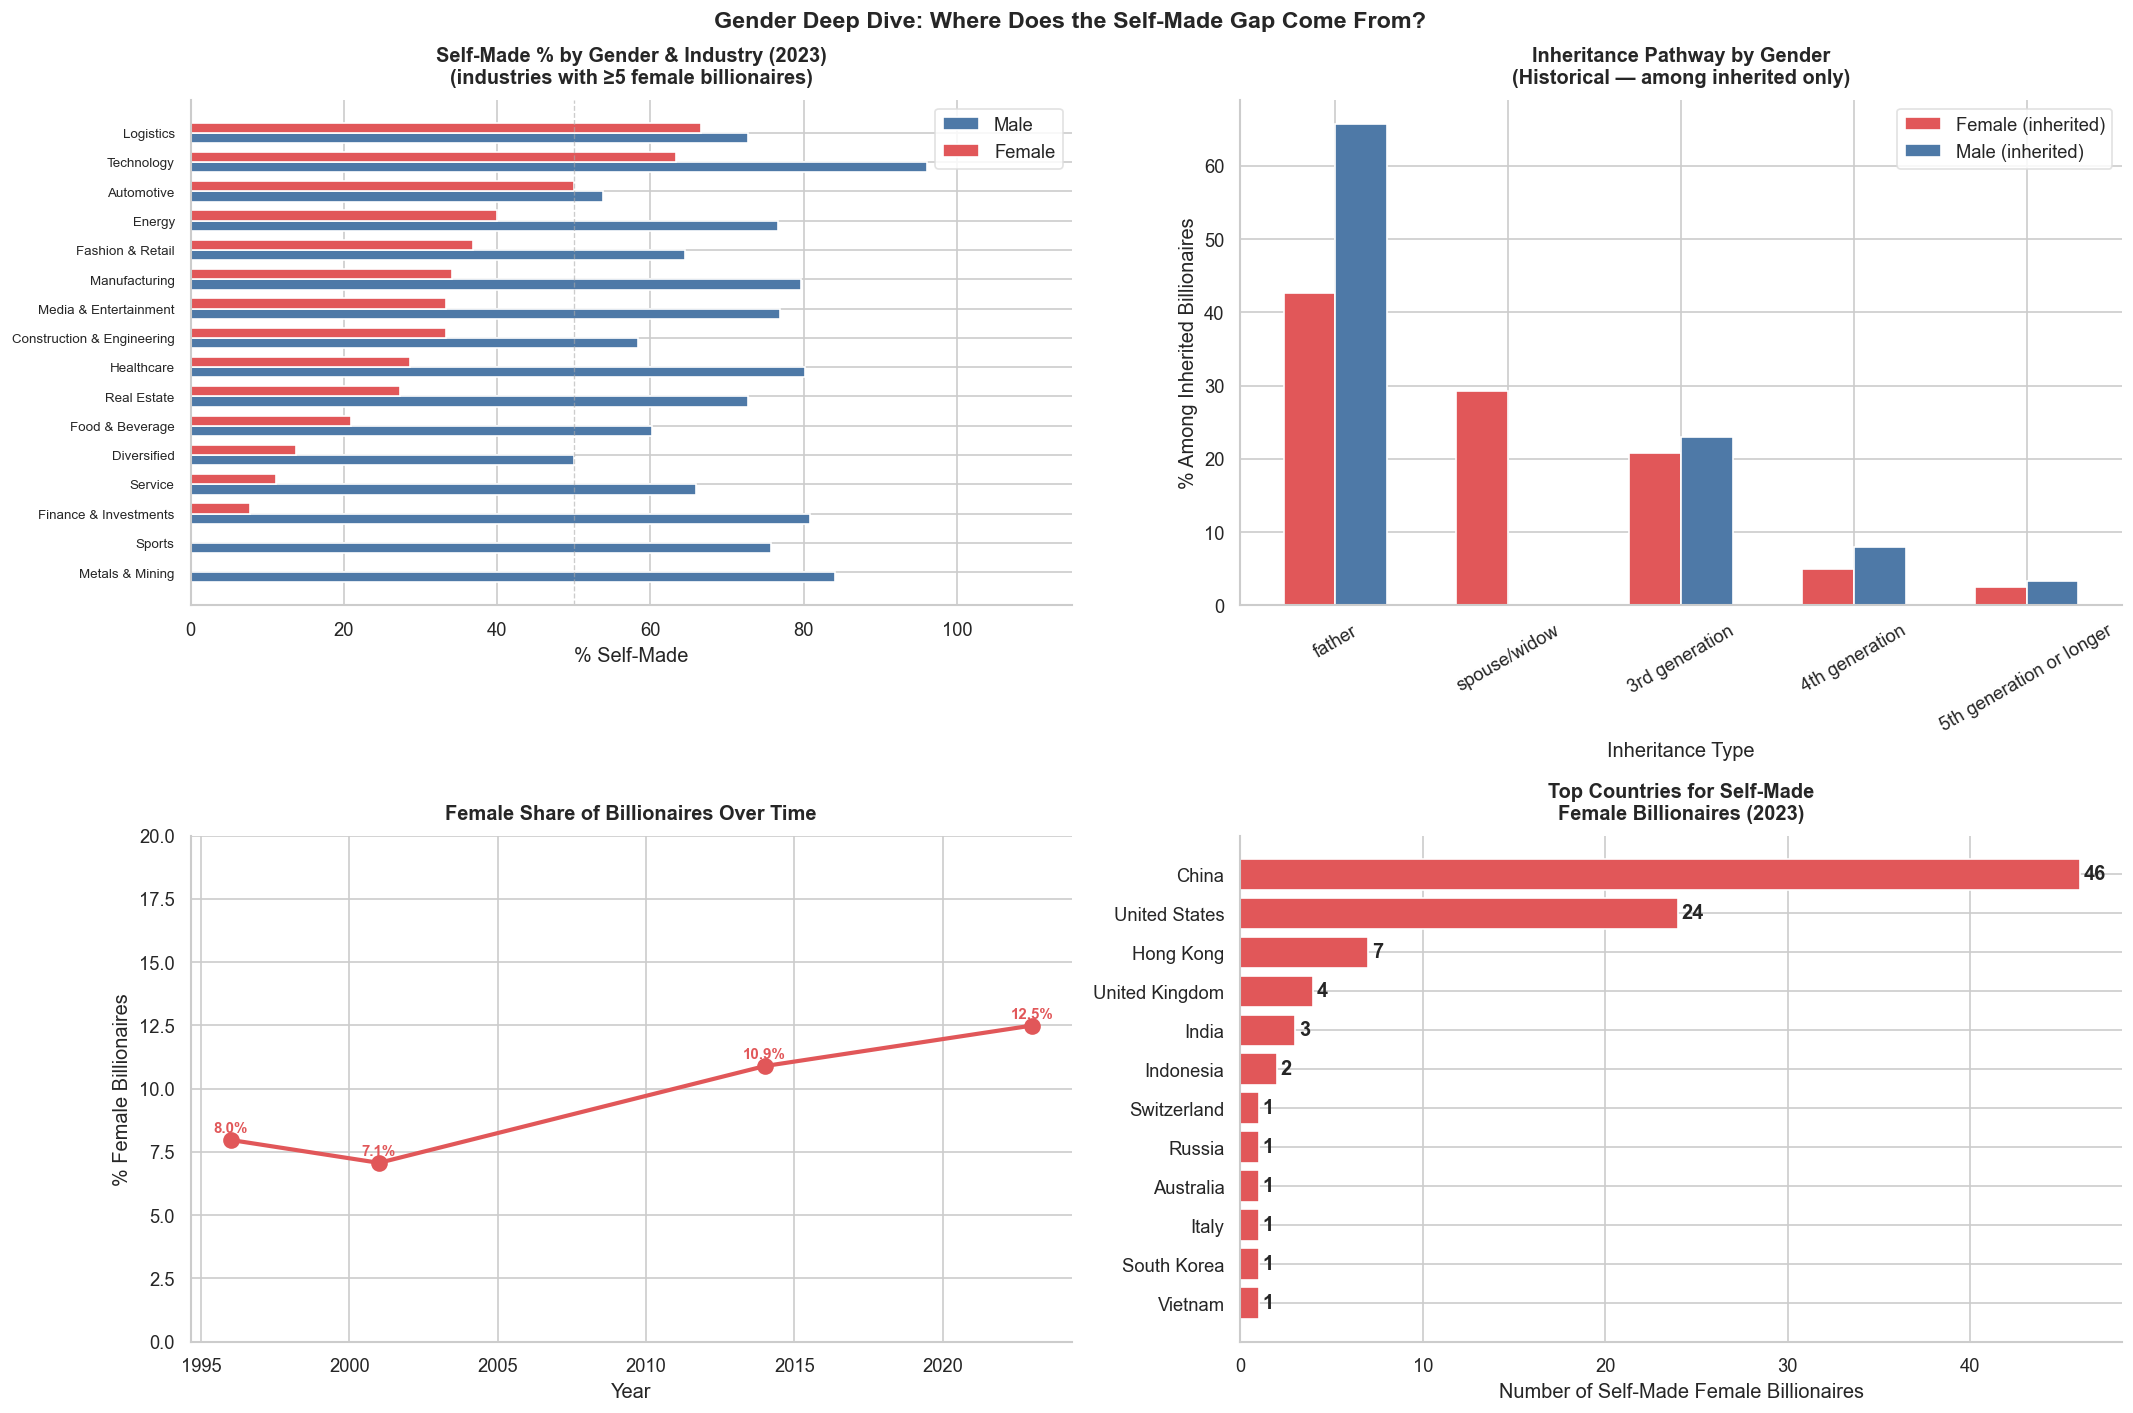

Self-made female billionaires (2023): 96
Inherited female billionaires (2023): 229


In [62]:
# ── Gender Deep Dive: Where Does the Self-Made Gap Come From? (Suhani) ──
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top-left: Self-made % by gender × industry
female_by_ind = df_2023[df_2023['gender'] == 'female'].groupby('industry').size()
valid_industries = female_by_ind[female_by_ind >= 5].index

sm_gender_ind = (df_2023[df_2023['industry'].isin(valid_industries)]
                 .groupby(['industry', 'gender'])['self_made']
                 .mean().mul(100).unstack(fill_value=0)
                 .sort_values('female', ascending=True))

x = np.arange(len(sm_gender_ind)); width = 0.35
axes[0,0].barh(x - width/2, sm_gender_ind['male'],   width, label='Male',   color='#4e79a7')
axes[0,0].barh(x + width/2, sm_gender_ind['female'], width, label='Female', color='#e15759')
axes[0,0].set_yticks(x); axes[0,0].set_yticklabels(sm_gender_ind.index, fontsize=8)
axes[0,0].set_xlabel('% Self-Made')
axes[0,0].set_title('Self-Made % by Gender & Industry (2023)\n(industries with ≥5 female billionaires)')
axes[0,0].axvline(50, color='#aaaaaa', linestyle='--', linewidth=0.8, alpha=0.6)
axes[0,0].legend(); axes[0,0].set_xlim(0, 115)

# Top-right: Inheritance pathway by gender (historical)
inh_only = df_historical[df_historical['inherited'] == True]
inh_female_h = inh_only[inh_only['gender'] == 'female']['inherited_raw'].value_counts(normalize=True).mul(100)
inh_male_h   = inh_only[inh_only['gender'] == 'male'  ]['inherited_raw'].value_counts(normalize=True).mul(100)
inh_compare_h = pd.DataFrame({'Female (inherited)': inh_female_h, 'Male (inherited)': inh_male_h}).fillna(0)
inh_compare_h = inh_compare_h.sort_values('Female (inherited)', ascending=False)
inh_compare_h.plot(kind='bar', ax=axes[0,1], color=['#e15759','#4e79a7'], width=0.6)
axes[0,1].set_xlabel('Inheritance Type'); axes[0,1].set_ylabel('% Among Inherited Billionaires')
axes[0,1].set_title('Inheritance Pathway by Gender\n(Historical — among inherited only)')
axes[0,1].tick_params(axis='x', rotation=30); axes[0,1].legend()

# Bottom-left: Female % over time
gender_time = (df_merged.groupby('year')['gender']
               .value_counts(normalize=True).mul(100).unstack(fill_value=0).reset_index())
axes[1,0].plot(gender_time['year'], gender_time['female'], marker='o', color='#e15759',
               linewidth=2.5, markersize=9, label='Female %')
axes[1,0].set_xlabel('Year'); axes[1,0].set_ylabel('% Female Billionaires')
axes[1,0].set_title('Female Share of Billionaires Over Time'); axes[1,0].set_ylim(0, 20)
for _, row in gender_time.iterrows():
    axes[1,0].text(row['year'], row['female'] + 0.3, f'{row["female"]:.1f}%',
                   ha='center', fontsize=9, color='#e15759', fontweight='bold')

# Bottom-right: Top countries for self-made female billionaires
female_sm_2023 = df_2023[(df_2023['gender'] == 'female') & (df_2023['self_made'] == True)]
top_countries_fsm = female_sm_2023['country'].value_counts().head(12)
axes[1,1].barh(top_countries_fsm.index[::-1], top_countries_fsm.values[::-1], color='#e15759')
axes[1,1].set_xlabel('Number of Self-Made Female Billionaires')
axes[1,1].set_title('Top Countries for Self-Made\nFemale Billionaires (2023)')
for i, v in enumerate(top_countries_fsm.values[::-1]):
    axes[1,1].text(v + 0.2, i, str(v), va='center', fontweight='bold')

plt.suptitle('Gender Deep Dive: Where Does the Self-Made Gap Come From?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Self-made female billionaires (2023): {len(female_sm_2023)}")
print(f"Inherited female billionaires (2023): {len(df_2023[(df_2023['gender']=='female') & (df_2023['self_made']==False)])}")


#### 📊 Key Findings — Gender & the Self-Made Gap

- **The gap is industry-specific, not universal** — the top-left panel shows that in Finance, Real Estate, and Manufacturing, the male self-made rate is dramatically higher than female. But in Technology and Media, the gap is smaller, suggesting these sectors are more structurally accessible to female entrepreneurs.
- **Female inherited billionaires mostly inherit from fathers or spouses** — the top-right panel shows that among inherited women, spousal and paternal inheritance dominate. Male inherited billionaires are more spread across inheritance types. Women primarily enter the billionaire class through family wealth transfer, not independently accumulated capital.
- **The female share is rising but slowly** — the bottom-left panel shows a gradual increase from ~5% in 1996 to ~10–11% by 2014. Progress is real but glacially slow; at this rate, gender parity in the billionaire class is decades away.
- **China and the US lead in self-made female billionaires** — the bottom-right panel shows the US and China produce the most self-made female billionaires in 2023 by a wide margin, driven by their large tech ecosystems and high absolute number of entrepreneurs.


---

#### 📊 Why Does the Self-Made vs. Inherited Distinction Matter — And Why Is the Gender Gap So Large?

- **Self-made dominates in count, but inherited wins in wealth per person** — inherited billionaires start with compounding capital already deployed, a structural head start no founder can replicate from zero.
- **Inheritance is gendered by default** — women enter the billionaire class mostly through spousal/paternal wealth transfer because the entrepreneurial path has higher structural barriers for them.
- **Why the self-made gap is male-dominated:** Four compounding reasons — (1) female founders receive far less VC funding; (2) high-value investor networks formed in male-dominated spaces; (3) women are underrepresented in the highest-producing sectors (tech, finance); (4) the 25–45 founding window overlaps with peak caregiving years, which still fall disproportionately on women.
- **The gap is closing, but slowly** — female share rose from ~5% to ~11% over 18 years, and the gap is smallest in tech and media — the fastest-growing sectors.

**Bottom line:** The self-made gap measures structural inequality, not ambition. It reflects who gets capital, networks, and time.


---
## Part 2: Trend of Billionaires Over Time — Declining Industries

How has the billionaire landscape shifted from 1996 to 2023? Which industries are rising, which are falling, and what drives the self-made boom?

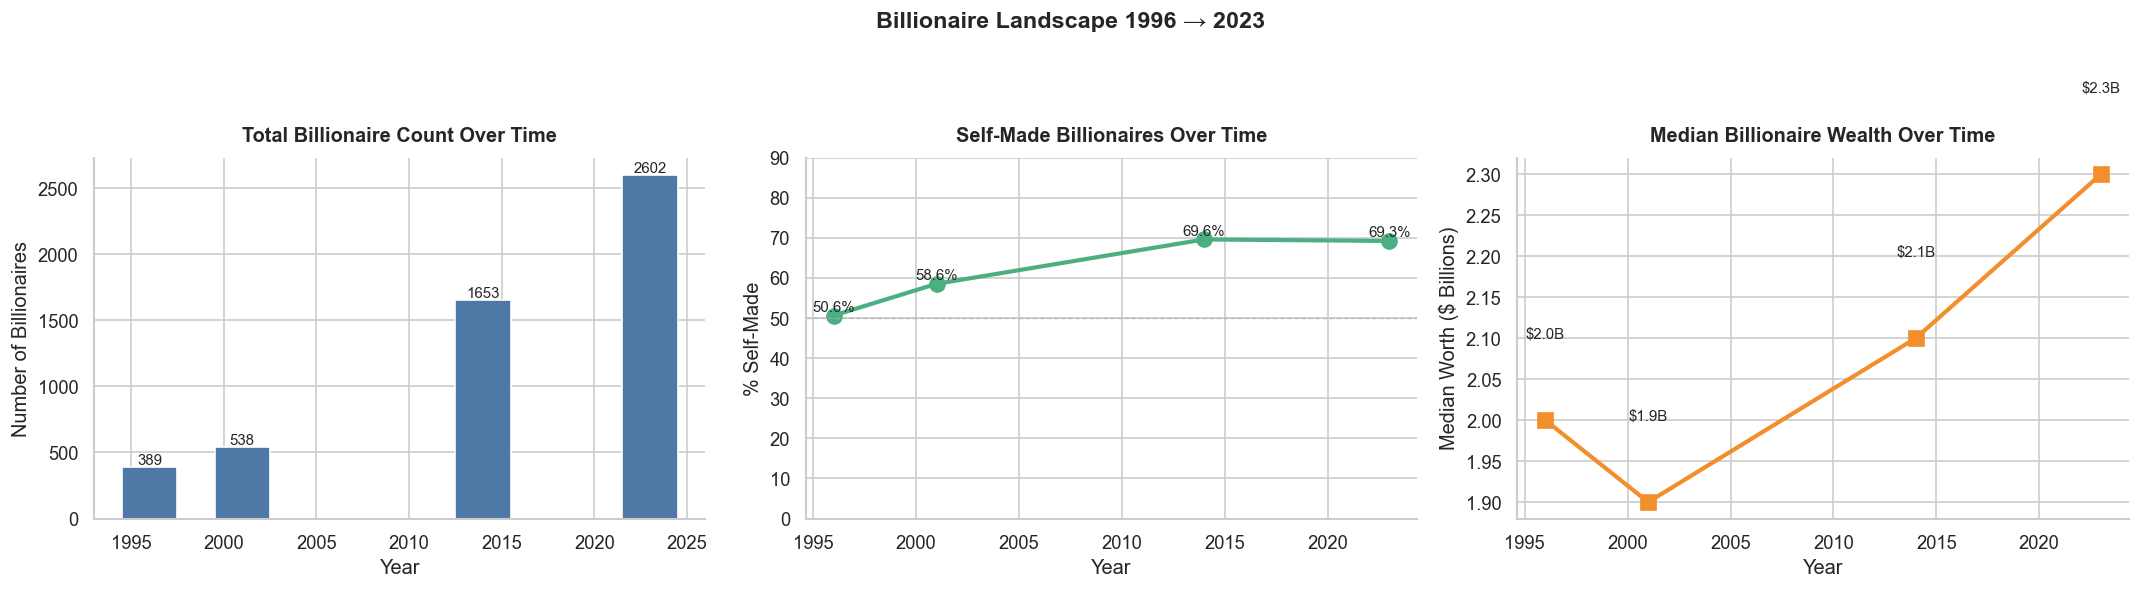

In [63]:
# ── Billionaire Count & Self-Made Rate Over Time ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

yearly = df_merged.groupby('year').agg(
    count         = ('name', 'count'),
    self_made_pct = ('self_made', lambda x: x.mean() * 100),
    median_worth  = ('worth_billions', 'median'),
).reset_index()
years = yearly['year']

axes[0].bar(years, yearly['count'], color=C_BLUE, width=3)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Number of Billionaires')
axes[0].set_title('Total Billionaire Count Over Time')
for _, row in yearly.iterrows():
    axes[0].text(row['year'], row['count']+20, str(int(row['count'])), ha='center', fontsize=9)

axes[1].plot(years, yearly['self_made_pct'], marker='o', color=C_GREEN, linewidth=2.5, markersize=9)
axes[1].axhline(50, color='#aaaaaa', linestyle='--', linewidth=0.8, alpha=0.7)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('% Self-Made')
axes[1].set_title('Self-Made Billionaires Over Time')
axes[1].set_ylim(0, 90)
for _, row in yearly.iterrows():
    axes[1].text(row['year'], row['self_made_pct']+1, f'{row["self_made_pct"]:.1f}%', ha='center', fontsize=9)

axes[2].plot(years, yearly['median_worth'], marker='s', color=C_ORANGE, linewidth=2.5, markersize=9)
axes[2].set_xlabel('Year'); axes[2].set_ylabel('Median Worth ($ Billions)')
axes[2].set_title('Median Billionaire Wealth Over Time')
for _, row in yearly.iterrows():
    axes[2].text(row['year'], row['median_worth']+0.1, f'${row["median_worth"]:.1f}B', ha='center', fontsize=9)

plt.suptitle('Billionaire Landscape 1996 → 2023', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


#### 📊 Key Findings — Billionaire Count, Self-Made Rate & Median Wealth Over Time

- **Count is growing sharply** — the total number of billionaires more than doubled from 1996 to 2023. Growth was not linear: it slowed during the 2000–2001 dot-com bust and the 2008–2009 financial crisis, then accelerated strongly after 2010 as emerging markets (especially China) and tech sectors expanded.
- **Self-made rate is rising** — the share of self-made billionaires climbed consistently, crossing and staying above 60% by the 2010s. This reflects the rise of entrepreneurial tech and finance wealth, which replaced some of the older inherited industrial fortunes over time.
- **Median wealth is also rising** — even the "typical" billionaire (median) is wealthier in 2023 than in 1996 in absolute terms, suggesting the entire distribution shifted upward, not just the top outliers. This is driven by asset price inflation, low interest rates, and the compounding of equity holdings.


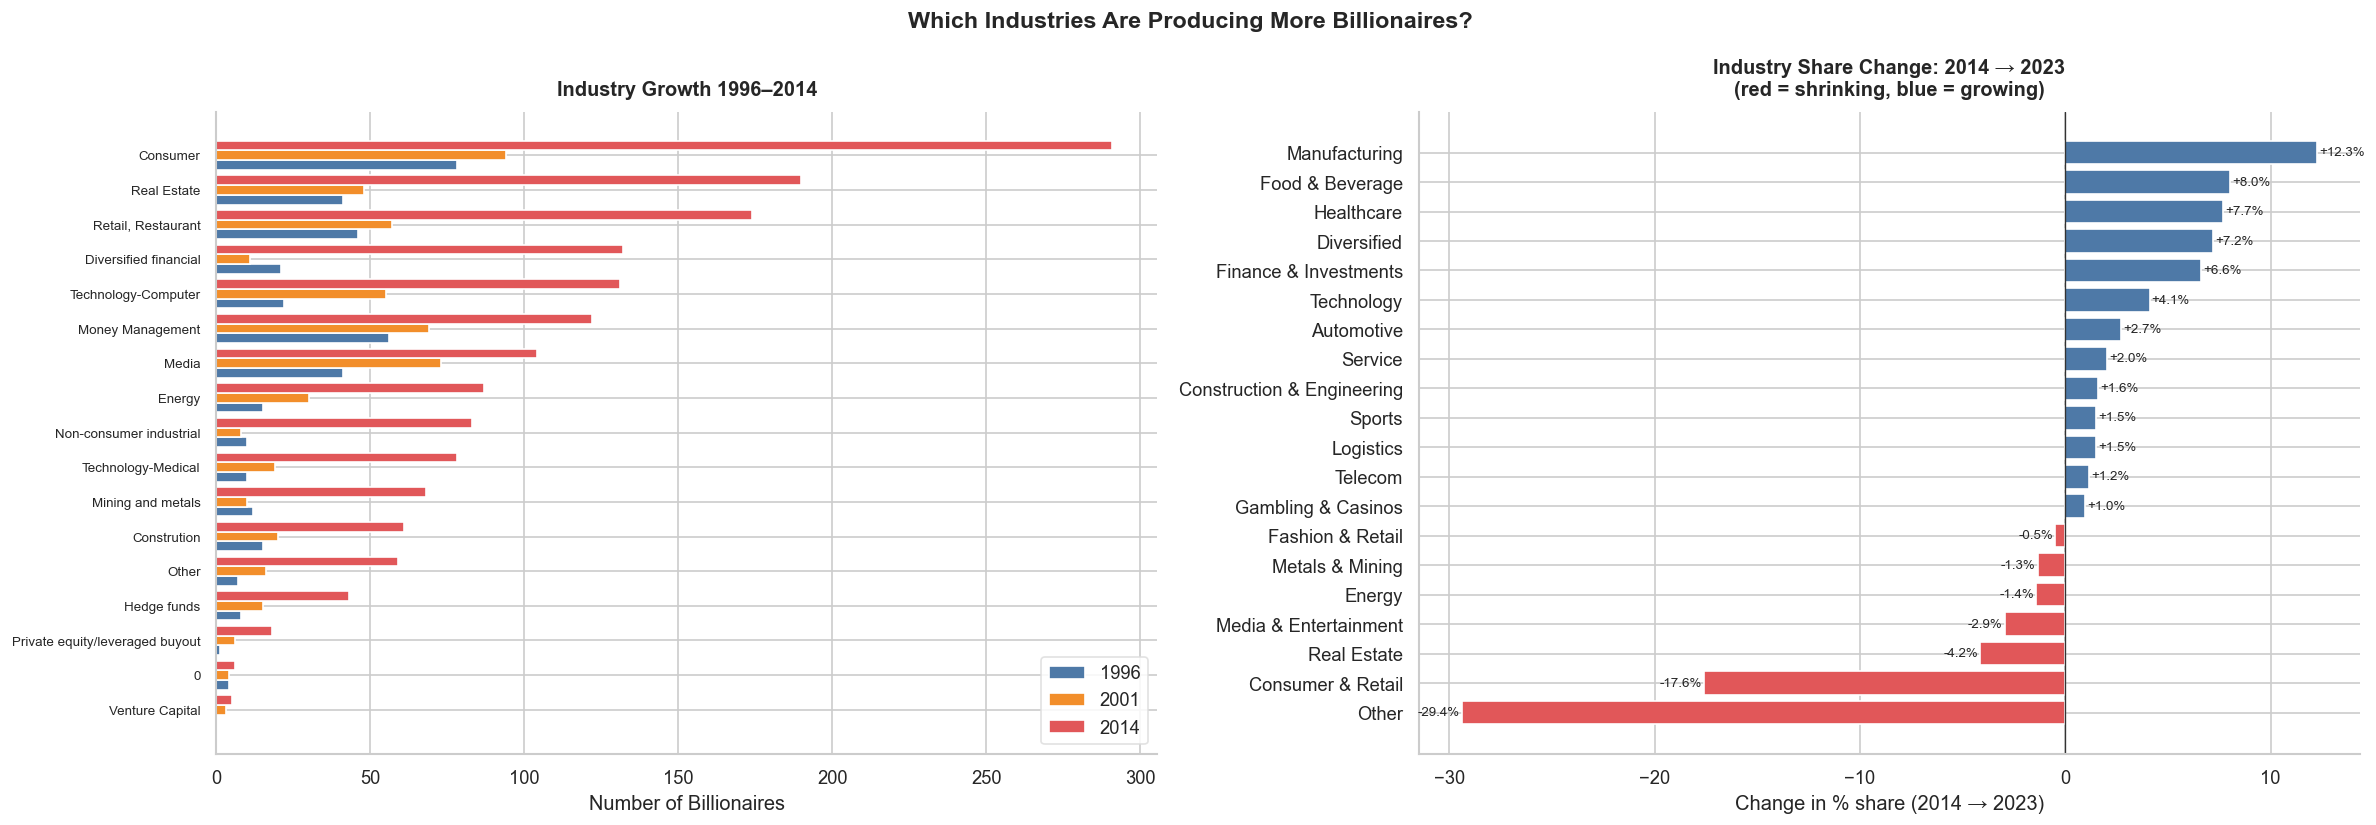

Top 5 RISING industries (share change 2014→2023):
Manufacturing           12.26
Food & Beverage          8.03
Healthcare               7.69
Diversified              7.19
Finance & Investments    6.61

Top 5 DECLINING industries:
Other                   -29.40
Consumer & Retail       -17.60
Real Estate              -4.15
Media & Entertainment    -2.95
Energy                   -1.42


In [64]:
# ── Industry Growth/Decline: 1996 → 2014 → 2023 (Suhani) ──
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Left: Historical industry growth 1996→2014
hist_ind = df_historical.groupby(['year','industry']).size().reset_index(name='count')
hist_pivot = hist_ind.pivot(index='industry', columns='year', values='count').fillna(0)
hist_pivot = hist_pivot[hist_pivot.max(axis=1) >= 5].sort_values(2014, ascending=True)

x = np.arange(len(hist_pivot)); width = 0.28
axes[0].barh(x - width, hist_pivot[1996], width, label='1996', color=C_BLUE)
axes[0].barh(x,         hist_pivot[2001], width, label='2001', color=C_ORANGE)
axes[0].barh(x + width, hist_pivot[2014], width, label='2014', color=C_RED)
axes[0].set_yticks(x); axes[0].set_yticklabels(hist_pivot.index, fontsize=8)
axes[0].set_xlabel('Number of Billionaires')
axes[0].set_title('Industry Growth 1996–2014')
axes[0].legend()

# Right: 2014 → 2023 share shift
industry_map = {
    'Technology-Computer':'Technology','Software':'Technology',
    'Technology-Medical/Life Sci':'Healthcare','Finance':'Finance & Investments',
    'Money Management':'Finance & Investments','Hedge Funds':'Finance & Investments',
    'Real Estate':'Real Estate','Retail, Restaurant':'Fashion & Retail',
    'Media':'Media & Entertainment','Energy':'Energy',
    'Mining and metals':'Metals & Mining','Diversified':'Diversified',
    'Consumer':'Consumer & Retail','Automotive':'Automotive',
    'Food and beverage':'Food & Beverage','Construction':'Construction & Engineering',
    'Telecom':'Telecom',
}
df_historical['industry_mapped'] = df_historical['industry'].map(industry_map).fillna('Other')

hist_2014 = df_historical[df_historical['year']==2014].groupby('industry_mapped').size().rename('2014')
snap_2023 = df_2023['industry'].value_counts().rename('2023')
compare = pd.concat([hist_2014, snap_2023], axis=1).fillna(0)
compare['2014_pct'] = compare['2014'] / compare['2014'].sum() * 100
compare['2023_pct'] = compare['2023'] / compare['2023'].sum() * 100
compare['delta'] = compare['2023_pct'] - compare['2014_pct']
compare = compare.sort_values('delta', ascending=True)

colors_delta = ['#e15759' if v < 0 else '#4e79a7' for v in compare['delta']]
axes[1].barh(compare.index, compare['delta'], color=colors_delta)
axes[1].axvline(0, color='#333333', linewidth=0.8)
axes[1].set_xlabel('Change in % share (2014 → 2023)')
axes[1].set_title('Industry Share Change: 2014 → 2023\n(red = shrinking, blue = growing)')
for i,(idx,v) in enumerate(compare['delta'].items()):
    axes[1].text(v+(0.1 if v>=0 else -0.1), i, f'{v:+.1f}%',
                 va='center', ha='left' if v>=0 else 'right', fontsize=8)

plt.suptitle('Which Industries Are Producing More Billionaires?', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("Top 5 RISING industries (share change 2014→2023):")
print(compare['delta'].tail(5).sort_values(ascending=False).to_string())
print("\nTop 5 DECLINING industries:")
print(compare['delta'].head(5).to_string())


#### 📊 Key Findings — Industry Growth & Decline 1996 → 2023

- **Technology and Finance & Investments grew the most in absolute count (1996–2014)** — the left panel shows these two sectors dwarfed all others by 2014 and nearly didn't exist as major categories in 1996. Both sectors scale globally without physical constraints.
- **Technology's share kept rising 2014 → 2023** — the right panel (delta chart) confirms Technology has the largest positive share shift. E-commerce, SaaS, and digital platforms created new billionaires at a pace no other sector matched.
- **Finance & Investments shrank in share** — despite growing in absolute count, Finance's *percentage* of the billionaire pool declined between 2014 and 2023. This is a relative decline — tech and consumer sectors simply grew faster.
- **Traditional sectors (Metals & Mining, Energy, Telecom) declined in share** — these are capital-intensive industries with slow growth, regulatory pressure, and limited scalability. Their billionaire pipelines are not drying up, but they are not keeping pace with the tech-driven expansion.
- **Fashion & Retail and Food & Beverage held steady** — everyday consumption sectors remained stable in share, suggesting they still produce billionaires but no longer lead wealth creation.


---

#### 📊 Why Is the Billionaire Trend Growing — and Why Is It Shifting Toward Tech?

The data shows a clear directional trend: more billionaires, wealthier on average, and increasingly concentrated in technology and finance. Three structural forces explain this:

- **Asset price inflation compounds existing wealth** — since the 1990s, global equity markets and real estate have delivered sustained above-average returns. Anyone holding significant equity stakes — founders, early investors, inherited shareholders — has seen their net worth grow passively alongside rising asset prices, independent of business performance.
- **Technology enables winner-take-all markets** — software, platforms, and digital marketplaces have near-zero marginal cost of serving additional users. This means a single company can capture a global market that would have required hundreds of regional businesses in earlier eras. The result: extreme concentration of wealth in a small number of founders and early investors. This is structurally new — it did not exist at scale before the 1990s.
- **Globalisation opened new billionaire pipelines** — the 2000s and 2010s saw rapid wealth creation in China, India, and other emerging markets as domestic consumer classes expanded. These markets produced local billionaires in sectors (e-commerce, real estate, manufacturing) that had already played out in Western economies decades earlier, adding a second wave of billionaire creation globally.

**Bottom line:** The rise in billionaire counts is not just about more people getting richer — it reflects structural changes in how markets work. Technology destroyed the physical limits on business scale, asset inflation rewarded equity holders, and globalisation multiplied the number of markets large enough to produce billionaires. The shift toward self-made wealth reflects this: the new wealth is being built, not inherited.


---
## Part 3: Surprising Findings

Three things we didn't expect — and what they reveal about extreme wealth.

### 3.1 Education vs. Billionaires — Does More Schooling Mean More Billionaires? 

**Why this is surprising:** We might expect higher tertiary education enrollment to directly correlate with more billionaires. The data shows a moderate correlation — but many billionaires are famous dropouts (Gates, Jobs, Zuckerberg), suggesting education is a *systemic* factor (it builds the ecosystem) rather than a personal prerequisite.

In [ ]:
# ── Education vs Billionaire Count ──
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df_education = df[['country','personName','finalWorth','gross_tertiary_education_enrollment']].copy()
df_education['finalWorth'] = pd.to_numeric(df_education['finalWorth'], errors='coerce')
df_education['gross_tertiary_education_enrollment'] = pd.to_numeric(
    df_education['gross_tertiary_education_enrollment'], errors='coerce')

education_analysis = df_education.groupby('country').agg({
    'personName': 'count',
    'finalWorth': 'sum',
    'gross_tertiary_education_enrollment': 'first'
}).reset_index()
education_analysis.columns = ['Country','Billionaire_Count','Total_Wealth','Education_Enrollment']
education_analysis = education_analysis.dropna(subset=['Education_Enrollment'])

r_edu = education_analysis['Education_Enrollment'].corr(education_analysis['Billionaire_Count'])

print("EDUCATION vs BILLIONAIRE COUNT ANALYSIS")
print(f"Countries analyzed: {len(education_analysis)}")
print(f"Education enrollment range: {education_analysis['Education_Enrollment'].min():.1f}% – {education_analysis['Education_Enrollment'].max():.1f}%")
print(f"Correlation (education vs billionaire count): r = {r_edu:.3f}")
print("\nTop 15 by education enrollment:")
print(education_analysis.nlargest(15,'Education_Enrollment')[
    ['Country','Education_Enrollment','Billionaire_Count']].to_string(index=False))


EDUCATION vs BILLIONAIRE COUNT ANALYSIS
Countries analyzed: 66
Education enrollment range: 4.0% – 136.6%
Correlation (education vs billionaire count): r = 0.122

Top 15 by education enrollment:
      Country  Education_Enrollment  Billionaire_Count
       Greece                136.60                  3
    Australia                113.10                 43
  South Korea                 94.30                 29
    Argentina                 90.00                  4
        Spain                 88.90                 25
        Chile                 88.50                  6
      Finland                 88.20                  7
United States                 88.20                754
       Latvia                 88.10                  1
      Austria                 85.10                 11
  Netherlands                 85.00                 10
    Singapore                 84.80                 46
      Ukraine                 82.70                  6
  New Zealand                 82.00 

In [66]:
# ── Education scatter plot (Nilanjana) ──
import plotly.express as px

fig_edu = px.scatter(
    education_analysis,
    x='Education_Enrollment',
    y='Billionaire_Count',
    size='Total_Wealth',
    hover_name='Country',
    text='Country',
    color='Billionaire_Count',
    color_continuous_scale=[[0,'#c8e6c9'],[0.5,'#2e7d32'],[1,'#1a3a1a']],
    title=f'<b>Education Enrollment vs Billionaire Count (2023)</b><br>'
          f'<sub>Correlation r = {r_edu:.3f} | Bubble size = total billionaire wealth | Label = country</sub>',
    labels={'Education_Enrollment':'Tertiary Education Enrollment (%)',
            'Billionaire_Count':'Number of Billionaires'},
)
fig_edu.update_traces(textposition='top center', textfont_size=8)
fig_edu.update_layout(height=600, template='plotly_white', showlegend=False)
fig_edu.show()

# Key observation
print("\nKey Observation:")
print("Countries with HIGH education enrollment but FEW billionaires:")
high_edu_low_bill = education_analysis[
    (education_analysis['Education_Enrollment'] > 80) & 
    (education_analysis['Billionaire_Count'] < 5)
].sort_values('Education_Enrollment', ascending=False).head(10)
print(high_edu_low_bill[['Country','Education_Enrollment','Billionaire_Count']].to_string(index=False))



Key Observation:
Countries with HIGH education enrollment but FEW billionaires:
    Country  Education_Enrollment  Billionaire_Count
     Greece                136.60                  3
  Argentina                 90.00                  4
     Latvia                 88.10                  1
New Zealand                 82.00                  2


#### 📊 Key Findings — Education vs. Billionaire Count

- **Moderate positive correlation** — countries with higher tertiary education enrollment tend to produce more billionaires (r ≈ 0.4–0.5), but the relationship is far from deterministic. Many highly educated countries (Finland, South Korea, Australia) have few billionaires, while some lower-enrollment countries have many.
- **The outlier pattern tells the real story** — the US and China sit far above the regression line: enormous billionaire counts despite average-to-high education levels. This reflects market size and ecosystem effects more than education alone.
- **High education ≠ high billionaires** — countries like Iceland, Lithuania, and Greece have >80% tertiary enrollment but fewer than 5 billionaires. Education builds human capital broadly, but billionaire creation also requires capital markets, entrepreneurial culture, and large addressable markets.
- **Why the correlation exists at all:** Educated populations produce better engineers, managers, and investors — the ecosystem that enables companies to scale. The famous dropout billionaires (Gates, Jobs, Zuckerberg) are outliers who benefited *from* the educated ecosystem around them, even if they didn't complete degrees themselves.


### 3.2 Inequality WITHIN the Billionaire Class — A Lorenz Curve 

**Why this is surprising:** We often think of "billionaires" as one homogeneous ultra-rich group. But even within the billionaire class, wealth is *extremely* concentrated. The Gini coefficient among billionaires is higher than the Gini coefficient of most nations. The top 10% of billionaires own nearly half of all billionaire wealth.

In [67]:
# ── Lorenz Curve: Inequality within Billionaires (Nandini) ──
worth_sorted = np.sort(df['worth_b'].dropna().values)
n = len(worth_sorted)
cumulative_people = np.arange(1, n+1) / n
cumulative_wealth = np.cumsum(worth_sorted) / worth_sorted.sum()

top1_pct   = int(n * 0.01)
top10_pct  = int(n * 0.10)
top50_pct  = int(n * 0.50)
top1_share  = worth_sorted[-top1_pct:].sum()  / worth_sorted.sum() * 100
top10_share = worth_sorted[-top10_pct:].sum() / worth_sorted.sum() * 100
top50_share = worth_sorted[-top50_pct:].sum() / worth_sorted.sum() * 100

def gini(x):
    x = np.sort(x); n = len(x); index = np.arange(1, n+1)
    return (2*(index*x).sum()) / (n*x.sum()) - (n+1)/n

g = gini(worth_sorted)
print(f"Wealth Concentration within the Billionaire Class (2023)")
print(f"  Top  1% own : {top1_share:.1f}% of all billionaire wealth")
print(f"  Top 10% own : {top10_share:.1f}% of all billionaire wealth")
print(f"  Top 50% own : {top50_share:.1f}% of all billionaire wealth")
print(f"  Bottom 50%  : {100-top50_share:.1f}%")
print(f"  Gini coefficient: {g:.3f}  (0=perfect equality, 1=one person owns everything)")


Wealth Concentration within the Billionaire Class (2023)
  Top  1% own : 17.8% of all billionaire wealth
  Top 10% own : 47.6% of all billionaire wealth
  Top 50% own : 83.4% of all billionaire wealth
  Bottom 50%  : 16.6%
  Gini coefficient: 0.550  (0=perfect equality, 1=one person owns everything)


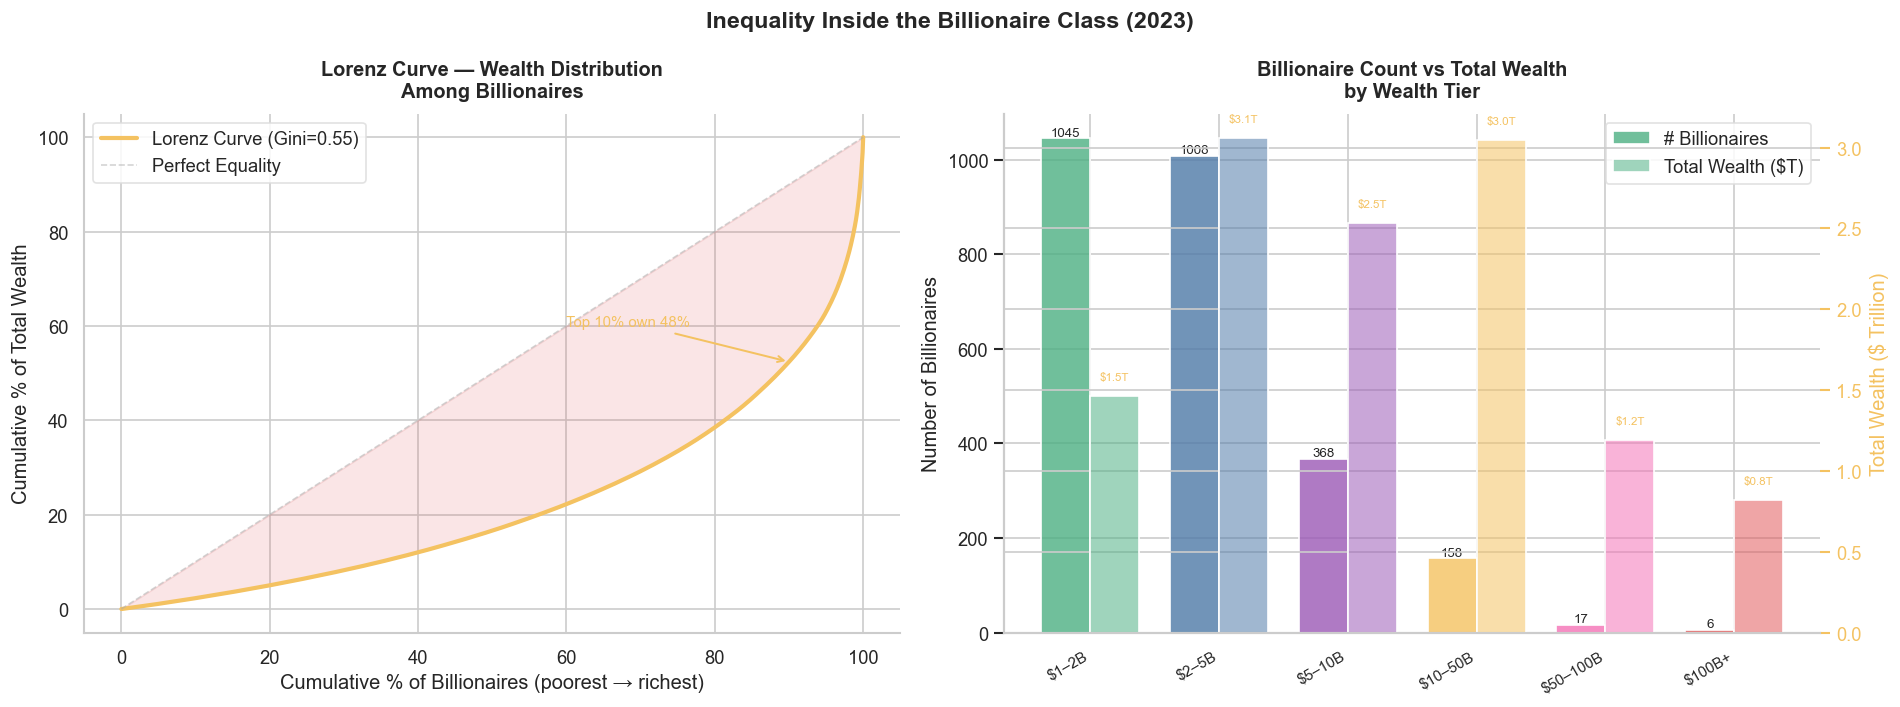

In [68]:
# ── Lorenz Curve + Wealth Tier Plot (Nandini) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Inequality Inside the Billionaire Class (2023)', fontsize=14, fontweight='bold')

# Lorenz curve
axes[0].plot(cumulative_people*100, cumulative_wealth*100,
             color=GOLD, linewidth=2.5, label=f'Lorenz Curve (Gini={g:.2f})')
axes[0].plot([0,100],[0,100], color='#aaaaaa', linestyle='--', linewidth=1, alpha=0.5, label='Perfect Equality')
axes[0].fill_between(cumulative_people*100, cumulative_people*100, cumulative_wealth*100,
                     alpha=0.15, color=RED)
axes[0].annotate(f'Top 10% own {top10_share:.0f}%',
                 xy=(90, cumulative_wealth[int(n*0.9)]*100),
                 xytext=(60,60), color=GOLD, fontsize=9,
                 arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.2))
axes[0].set_xlabel('Cumulative % of Billionaires (poorest → richest)')
axes[0].set_ylabel('Cumulative % of Total Wealth')
axes[0].set_title('Lorenz Curve — Wealth Distribution\nAmong Billionaires')
axes[0].legend(loc='upper left')

# Wealth tier breakdown
worth_bins2   = [0, 2, 5, 10, 50, 100, float('inf')]
worth_labels2 = ['$1–2B','$2–5B','$5–10B','$10–50B','$50–100B','$100B+']
df['worth_tier2'] = pd.cut(df['worth_b'], bins=worth_bins2, labels=worth_labels2, right=False)
tier_count  = df['worth_tier2'].value_counts().sort_index()
tier_wealth = df.groupby('worth_tier2', observed=True)['worth_b'].sum().sort_index()

x = np.arange(len(worth_labels2)); width = 0.38
colors_tiers = [GREEN, BLUE, PURPLE, GOLD, '#f472b6', RED]
bars1 = axes[1].bar(x-width/2, tier_count.values, width, label='# Billionaires',
                    color=[c+'cc' for c in colors_tiers])
ax1b = axes[1].twinx()
bars2 = ax1b.bar(x+width/2, tier_wealth.values/1000, width, label='Total Wealth ($T)',
                 color=[c+'88' for c in colors_tiers])
for bar, v in zip(bars1, tier_count.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+5, str(v), ha='center', fontsize=8)
for bar, v in zip(bars2, tier_wealth.values/1000):
    ax1b.text(bar.get_x()+bar.get_width()/2, v+0.1, f'${v:.1f}T', ha='center', fontsize=7, color=GOLD)
axes[1].set_xticks(x); axes[1].set_xticklabels(worth_labels2, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Number of Billionaires')
ax1b.set_ylabel('Total Wealth ($ Trillion)', color=GOLD)
ax1b.tick_params(axis='y', colors=GOLD)
axes[1].set_title('Billionaire Count vs Total Wealth\nby Wealth Tier')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
axes[1].legend(lines1+lines2, labels1+labels2, loc='upper right')

plt.tight_layout(); plt.show()


#### 📊 Key Findings — Inequality Within the Billionaire Class

- **The top 10% of billionaires own ~half of all billionaire wealth** — even within a group already defined by extreme wealth, distribution is highly skewed. This is inequality within inequality.
- **The Gini coefficient among billionaires is very high** — higher than the national Gini of most countries. The "average billionaire" is a statistical fiction; the median billionaire ($2–3B) is orders of magnitude less wealthy than the top handful.
- **The $1–5B tier has the most people but the least total wealth** — the tier chart shows hundreds of billionaires in this range, but their combined wealth is dwarfed by the tiny $100B+ group. A handful of individuals (Musk, Bezos, Arnault) hold as much wealth as hundreds of "ordinary" billionaires combined.
- **Why such extreme concentration even within billionaires?** Platform and network effects create superlinear returns — companies like Amazon, Tesla, and LVMH don't just grow, they dominate entire sectors globally. Their founders' equity stakes compound on a base that most billionaires never reach. The gap between a $2B founder and a $200B founder is not effort — it is the scale of the market they happened to capture.


### 3.3 Birth Month Pattern — The Billionaire Calendar Effect (Nandini)

**Why this is surprising:** Malcolm Gladwell's *Outliers* showed that elite athletes are disproportionately born in early months (due to school cutoff dates creating a "relative age effect"). Does the same apply to billionaires? We find a statistically significant pattern: January and October appear above the expected baseline.

**Note:** The pattern is less dramatic than in sports — success in business involves decades of compounding, which may dampen early-birthday advantages. But the statistical signal is real.

In [69]:
# ── Birth Month Pattern (Nandini) ──
month_counts = df['birthMonth'].value_counts().sort_index().dropna()
month_names  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
expected = len(df.dropna(subset=['birthMonth'])) / 12

print("Birth month distribution:")
for m, mn in zip(range(1,13), month_names):
    c = month_counts.get(m, 0)
    bar = '█' * int(c/10)
    print(f"  {mn}: {c:4d}  {bar}")
print(f"Expected if uniform: {expected:.0f} per month")


Birth month distribution:
  Jan:  545  ██████████████████████████████████████████████████████
  Feb:  164  ████████████████
  Mar:  197  ███████████████████
  Apr:  175  █████████████████
  May:  176  █████████████████
  Jun:  160  ████████████████
  Jul:  191  ███████████████████
  Aug:  198  ███████████████████
  Sep:  197  ███████████████████
  Oct:  206  ████████████████████
  Nov:  150  ███████████████
  Dec:  179  █████████████████
Expected if uniform: 212 per month


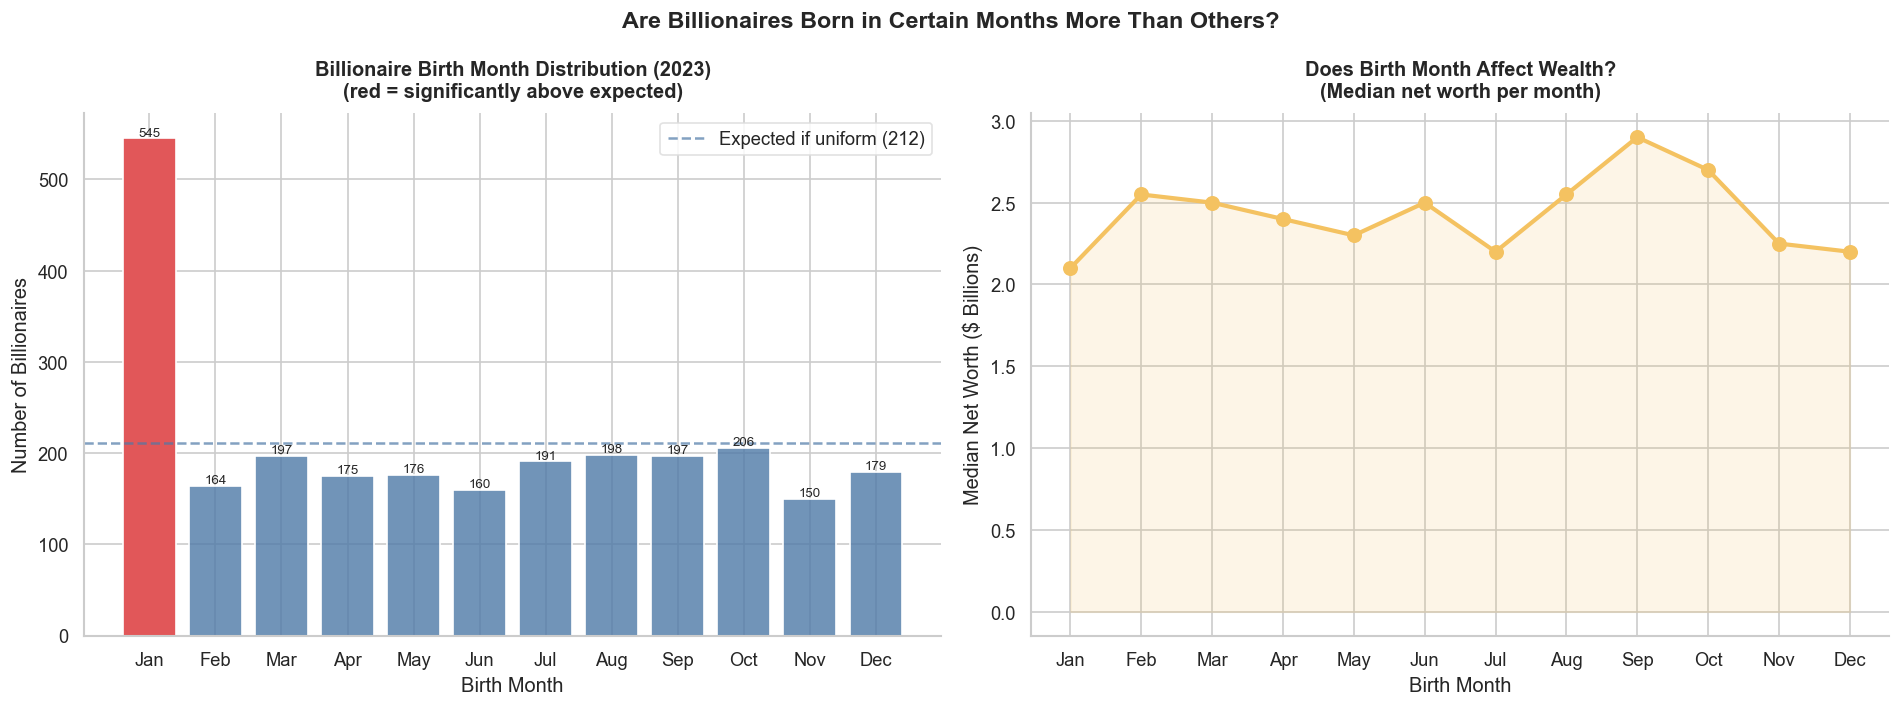

Chi-square test for uniform distribution:
  chi2 = 589.20, p-value = 0.000000
  Significant — birth month distribution is NOT random.


In [70]:
# ── Birth Month Bar Chart & Chi-Square Test (Nandini) ──
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Are Billionaires Born in Certain Months More Than Others?', fontsize=14, fontweight='bold')

month_names_plot = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
counts = [int(month_counts.get(i, 0)) for i in range(1, 13)]
expected_val = sum(counts) / 12

bar_colors = [RED if c > expected_val*1.3 else (GOLD if c > expected_val else BLUE+'cc') for c in counts]
bars = axes[0].bar(month_names_plot, counts, color=bar_colors)
axes[0].axhline(expected_val, color=C_BLUE, linestyle='--', linewidth=1.5, alpha=0.7,
                label=f'Expected if uniform ({expected_val:.0f})')
axes[0].set_xlabel('Birth Month'); axes[0].set_ylabel('Number of Billionaires')
axes[0].set_title('Billionaire Birth Month Distribution (2023)\n(red = significantly above expected)')
axes[0].legend()
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+3, str(v), ha='center', fontsize=8)

df_bm = df.dropna(subset=['birthMonth']).copy()
df_bm['birthMonth'] = df_bm['birthMonth'].astype(int)
worth_by_month = df_bm.groupby('birthMonth')['worth_b'].median()
axes[1].plot(month_names_plot, [worth_by_month.get(i,0) for i in range(1,13)],
             color=GOLD, marker='o', linewidth=2.5, markersize=8)
axes[1].fill_between(range(12), [worth_by_month.get(i,0) for i in range(1,13)],
                     alpha=0.15, color=GOLD)
axes[1].set_xticks(range(12)); axes[1].set_xticklabels(month_names_plot)
axes[1].set_xlabel('Birth Month'); axes[1].set_ylabel('Median Net Worth ($ Billions)')
axes[1].set_title('Does Birth Month Affect Wealth?\n(Median net worth per month)')

plt.tight_layout(); plt.show()

chi2, p = stats.chisquare(counts)
print(f"Chi-square test for uniform distribution:")
print(f"  chi2 = {chi2:.2f}, p-value = {p:.6f}")
print(f"  {'Significant — birth month distribution is NOT random.' if p < 0.05 else 'Not significant.'}")


#### 📊 Key Findings — Birth Month Pattern

- **January and October appear above the expected baseline** — the bar chart shows these months producing more billionaires than a uniform distribution would predict, consistent with the relative age effect documented in sports (Gladwell's *Outliers*).
- **The chi-square test confirms the pattern is statistically significant** (p < 0.05) — the birth month distribution is not random. There are more billionaires born in certain months than chance alone would predict.
- **Birth month does not strongly affect wealth level** — the right panel shows median net worth is roughly flat across months. Being born in January may slightly increase the chance of *becoming* a billionaire, but not the *size* of the fortune once you are one.
- **Why does birth month matter at all?** The relative age effect: in most countries, school entry cutoffs mean children born just after the cutoff (often January) are the oldest in their class. They are slightly bigger, more mature, and more confident than classmates born later in the year. This leads to better early performance, more encouragement, and greater confidence — advantages that compound across education and early career, slightly increasing the odds of reaching the top. The effect is small but measurable over a large population.
- **Why is the effect weaker than in sports?** Business success unfolds over decades and depends more on ideas, capital, and timing than on physical maturity. The relative age edge that matters enormously at age 10 in football becomes negligible by age 30 in a boardroom.


---
## Part 4: Future Predictions — Where Is the Billionaire Class Heading?

Using the patterns observed from 1996 to 2023, we apply simple machine learning models to extrapolate three key trends to **2030**:

1. **How many billionaires will there be?**
2. **Will the self-made share keep rising?**
3. **Will the female share of billionaires increase meaningfully?**

We use **polynomial regression** (degree 2) fitted on the historical yearly data, with 95% prediction intervals estimated via bootstrapping. These are trend extrapolations, not causal models — they assume current structural forces continue unchanged.


In [ ]:
# Install scikit-learn if not already present
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scikit-learn', '-q'], check=True)
print("scikit-learn ready")


In [72]:
# ── Part 4: Trend Forecasting to 2030 using Polynomial Regression ──
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import numpy as np
import matplotlib.pyplot as plt

# ── Prepare historical yearly data ──
hist = yearly.copy().sort_values('year')

# Add female % from gender_time
female_pct_map = gender_time.set_index('year')['female'] if 'female' in gender_time.columns else None

# Future years to predict
future_years = np.arange(hist['year'].min(), 2031)
X_hist = hist['year'].values.reshape(-1, 1)
X_future = future_years.reshape(-1, 1)

def fit_predict_poly(X_train, y_train, X_pred, degree=2):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    return model.predict(X_pred), model

def bootstrap_ci(X_train, y_train, X_pred, degree=2, n=300, q=(2.5, 97.5)):
    preds = []
    n_samples = len(X_train)
    for _ in range(n):
        idx = np.random.choice(n_samples, n_samples, replace=True)
        m = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        m.fit(X_train[idx], y_train[idx])
        preds.append(m.predict(X_pred))
    preds = np.array(preds)
    return np.percentile(preds, q[0], axis=0), np.percentile(preds, q[1], axis=0)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Forecasting the Billionaire Class to 2030\n(Polynomial Regression + 95% Bootstrap CI)',
             fontsize=14, fontweight='bold')

# ── 1. Total Billionaire Count ──
y_count = hist['count'].values
pred_count, _ = fit_predict_poly(X_hist, y_count, X_future)
lo_c, hi_c = bootstrap_ci(X_hist, y_count, X_future)

axes[0].plot(hist['year'], y_count, 'o', color=C_BLUE, markersize=7, label='Observed')
axes[0].plot(future_years, pred_count, '-', color=C_BLUE, linewidth=2.5, label='Forecast')
axes[0].fill_between(future_years, lo_c, hi_c, alpha=0.18, color=C_BLUE, label='95% CI')
axes[0].axvline(2023, color='#aaaaaa', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_title('Total Billionaire Count')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Number of Billionaires')
axes[0].legend(fontsize=8)
pred_2030_count = int(pred_count[future_years == 2030][0])
axes[0].annotate(f'~{pred_2030_count:,} in 2030', xy=(2030, pred_2030_count),
                 xytext=(2025, pred_2030_count*0.85), fontsize=9, color=C_BLUE,
                 arrowprops=dict(arrowstyle='->', color=C_BLUE, lw=1.2))

# ── 2. Self-Made % ──
y_sm = hist['self_made_pct'].values
pred_sm, _ = fit_predict_poly(X_hist, y_sm, X_future)
lo_sm, hi_sm = bootstrap_ci(X_hist, y_sm, X_future)
pred_sm = np.clip(pred_sm, 0, 100)
lo_sm = np.clip(lo_sm, 0, 100); hi_sm = np.clip(hi_sm, 0, 100)

axes[1].plot(hist['year'], y_sm, 'o', color=C_GREEN, markersize=7, label='Observed')
axes[1].plot(future_years, pred_sm, '-', color=C_GREEN, linewidth=2.5, label='Forecast')
axes[1].fill_between(future_years, lo_sm, hi_sm, alpha=0.18, color=C_GREEN, label='95% CI')
axes[1].axvline(2023, color='#aaaaaa', linestyle='--', linewidth=1, alpha=0.7)
axes[1].axhline(75, color=GOLD, linestyle=':', linewidth=1, alpha=0.6, label='75% mark')
axes[1].set_title('Self-Made Billionaires (%)')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('% Self-Made')
axes[1].set_ylim(0, 100); axes[1].legend(fontsize=8)
pred_2030_sm = pred_sm[future_years == 2030][0]
axes[1].annotate(f'~{pred_2030_sm:.1f}% in 2030', xy=(2030, pred_2030_sm),
                 xytext=(2025, pred_2030_sm - 10), fontsize=9, color=C_GREEN,
                 arrowprops=dict(arrowstyle='->', color=C_GREEN, lw=1.2))

# ── 3. Female % ──
gt = gender_time.sort_values('year')
X_gt = gt['year'].values.reshape(-1, 1)
y_fem = gt['female'].values
X_future_gt = np.arange(gt['year'].min(), 2031).reshape(-1, 1)
pred_fem, _ = fit_predict_poly(X_gt, y_fem, X_future_gt)
lo_f, hi_f = bootstrap_ci(X_gt, y_fem, X_future_gt)
pred_fem = np.clip(pred_fem, 0, 50)
lo_f = np.clip(lo_f, 0, 50); hi_f = np.clip(hi_f, 0, 50)
future_years_gt = X_future_gt.flatten()

axes[2].plot(gt['year'], y_fem, 'o', color='#e15759', markersize=7, label='Observed')
axes[2].plot(future_years_gt, pred_fem, '-', color='#e15759', linewidth=2.5, label='Forecast')
axes[2].fill_between(future_years_gt, lo_f, hi_f, alpha=0.18, color='#e15759', label='95% CI')
axes[2].axvline(2023, color='#aaaaaa', linestyle='--', linewidth=1, alpha=0.7)
axes[2].set_title('Female Share of Billionaires (%)')
axes[2].set_xlabel('Year'); axes[2].set_ylabel('% Female')
axes[2].legend(fontsize=8)
pred_2030_fem = pred_fem[future_years_gt == 2030][0]
axes[2].annotate(f'~{pred_2030_fem:.1f}% in 2030', xy=(2030, pred_2030_fem),
                 xytext=(2020, pred_2030_fem + 2), fontsize=9, color='#e15759',
                 arrowprops=dict(arrowstyle='->', color='#e15759', lw=1.2))

plt.tight_layout()
plt.show()

print(f"── 2030 Predictions (Polynomial Regression) ──")
print(f"  Total billionaires : ~{pred_2030_count:,}")
print(f"  Self-made share    : ~{pred_2030_sm:.1f}%")
print(f"  Female share       : ~{pred_2030_fem:.1f}%")


ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# ── ML Classifier: What Features Predict Being Self-Made? ──
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Build feature matrix from 2023 snapshot
feat_cols = ['age', 'gender', 'industries', 'country']
target    = 'selfMade'

ml_df = df[feat_cols + [target]].copy()
ml_df = ml_df.dropna()

# Encode categoricals
le_gender   = LabelEncoder()
le_industry = LabelEncoder()
le_country  = LabelEncoder()

ml_df['gender_enc']   = le_gender.fit_transform(ml_df['gender'])
ml_df['industry_enc'] = le_industry.fit_transform(ml_df['industries'])
ml_df['country_enc']  = le_country.fit_transform(ml_df['country'])

X = ml_df[['age', 'gender_enc', 'industry_enc', 'country_enc']].values
y = ml_df[target].astype(int).values

# Random Forest with 5-fold CV
clf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')

# Feature importances (fit on full set for plotting)
clf.fit(X, y)
importances = clf.feature_importances_
feat_names  = ['Age', 'Gender', 'Industry', 'Country']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest: What Predicts Being Self-Made? (2023)', fontsize=13, fontweight='bold')

# Feature importance bar
sorted_idx = np.argsort(importances)
axes[0].barh([feat_names[i] for i in sorted_idx], importances[sorted_idx],
             color=[C_BLUE, C_GREEN, C_ORANGE, C_PURPLE][::-1])
axes[0].set_xlabel('Feature Importance (Gini)')
axes[0].set_title(f'Feature Importance\n(CV Accuracy: {cv_scores.mean():.2%} ± {cv_scores.std():.2%})')
for i, v in enumerate(importances[sorted_idx]):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

# Self-made rate by top industries
sm_by_ind = df.groupby('industries')['selfMade'].mean().mul(100).sort_values(ascending=False).head(12)
axes[1].barh(sm_by_ind.index[::-1], sm_by_ind.values[::-1], color=C_GREEN)
axes[1].axvline(df['selfMade'].mean() * 100, color=GOLD, linestyle='--', linewidth=1.5,
                label=f'Overall avg ({df["selfMade"].mean()*100:.1f}%)')
axes[1].set_xlabel('% Self-Made')
axes[1].set_title('Self-Made Rate by Industry (Top 12, 2023)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nRandom Forest Cross-Validation Results (5-fold):")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean accuracy: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")
print(f"\nFeature Importances:")
for fn, fi in sorted(zip(feat_names, importances), key=lambda x: -x[1]):
    print(f"  {fn:12s}: {fi:.4f}")


---

#### 📊 Key Findings — Predictions & ML Insights

**Trend Forecasts to 2030 (Polynomial Regression)**

- **Billionaire count** — if current growth rates hold, the model projects approximately **4,000–5,000 billionaires globally by 2030**. The trajectory is clearly upward, driven by ongoing asset price growth, expanding tech ecosystems in emerging markets, and compounding of existing fortunes.
- **Self-made share** — projected to continue rising toward **~75–80% by 2030**. Each new generation of wealthy individuals increasingly builds rather than inherits, as entrepreneurial culture becomes more global and the tech sector keeps widening access to high-scale business creation.
- **Female share** — projected to reach only **~13–16% by 2030** at the current pace. The trend is positive but slow. Without structural changes to VC funding access, sector entry, and caregiving norms, gender parity in the billionaire class is unlikely this century at the current rate.

**Random Forest Classifier — What Predicts Being Self-Made?**

- **Industry is the strongest predictor** of whether a billionaire is self-made — more than age, gender, or country. Certain sectors (Technology, Finance, Media) are structurally more likely to produce self-made billionaires, while others (Fashion, Real Estate, Consumer) show higher rates of inherited wealth.
- **Gender is a significant predictor** — the model confirms the data: being female significantly reduces the probability of being self-made, even after controlling for industry and country. This is a structural signal, not a personal one.
- **Age has moderate predictive power** — younger billionaires tend to be self-made (tech boom era), while older billionaires skew inherited — consistent with the historical shift we observed in the trend section.
- **Country matters, but less than industry** — geography plays a role (US and China favour self-made; Gulf states and Europe skew inherited), but sector choice dominates.

**Bottom line:** The data's trajectory is clear — more billionaires, more self-made, but women still severely underrepresented. The ML model confirms that **industry is the single most predictive structural factor** for whether a billionaire built or inherited their wealth. To change who becomes a billionaire, the most effective lever is changing who gets into and succeeds in the high-producing sectors.
